In [2]:
import re
from collections import defaultdict
from pathlib import Path   # <- you need this

# Full path to your log file
LOG_FILE = Path(r"C:\Users\bikep\IdeaProjects\myMicroRTSBot\10iterationsNewBots.txt")

def parse_log(path: Path):
    with path.open("r", encoding="utf-8") as f:
        lines = [l.strip() for l in f if l.strip()]

    # pattern for: Winner: 1  in 1045 cycles
    win_re = re.compile(r"Winner:\s*-?\d+\s+in\s+(\d+)\s+cycles")
    # pattern for: MATCH UP: A vs B
    match_re = re.compile(r"MATCH UP:\s*(.+?)\s+vs\s+(.+)")

    bot_cycles = defaultdict(list)

    i = 0
    while i < len(lines) - 1:
        win_m = win_re.match(lines[i])
        match_m = match_re.match(lines[i + 1])
        if win_m and match_m:
            cycles = int(win_m.group(1))
            bot1 = match_m.group(1).strip()
            bot2 = match_m.group(2).strip()

            bot_cycles[bot1].append(cycles)
            bot_cycles[bot2].append(cycles)

            i += 2
        else:
            i += 1

    return bot_cycles

def compute_averages(bot_cycles):
    stats = []
    for bot, vals in bot_cycles.items():
        avg = sum(vals) / len(vals)
        stats.append((bot, len(vals), avg))
    stats.sort(key=lambda x: x[2], reverse=True)
    return stats

def main():
    bot_cycles = parse_log(LOG_FILE)
    stats = compute_averages(bot_cycles)

    print("Bot, NumGames, AvgCycles")
    for bot, n_games, avg in stats:
        print(f"{bot}, {n_games}, {avg:.1f}")

if __name__ == "__main__":
    main()


Bot, NumGames, AvgCycles
WorkerDefense(AStarPathFinding), 200, 2211.7
Aggrobot(AStarPathFinding), 199, 1780.5
Tiamat(AStarPathFinding), 199, 1587.1
WorkerRushPlusPlus(AStarPathFinding), 200, 1505.7
POLightRush(AStarPathFinding), 200, 820.5
RandomBiasedAI, 200, 757.1
mayari, 200, 728.5
TMA, 200, 703.4
CoacAI(AStarPathFinding), 200, 686.2
TsuneBot, 200, 668.7
ObiBotKenobi, 200, 601.9


In [20]:
import re
from collections import defaultdict
from pathlib import Path

# Full path to your log file
LOG_FILE = Path(r"C:\Users\bikep\IdeaProjects\myMicroRTSBot\8x8-newIterations.txt")

def parse_log(path: Path):
    with path.open("r", encoding="utf-8") as f:
        lines = [l.strip() for l in f if l.strip()]

    win_re = re.compile(r"Winner:\s*(-?\d+)\s+in\s+(\d+)\s+cycles")
    match_re = re.compile(r"MATCH UP:\s*(.+?)\s+vs\s+(.+)")

    bot_cycles = defaultdict(list)
    all_cycles = []
    game_count = 0          # count games with winner != -1

    i = 0
    while i < len(lines) - 1:
        win_m = win_re.match(lines[i])
        match_m = match_re.match(lines[i + 1])
        if win_m and match_m:
            winner_flag = int(win_m.group(1))
            cycles = int(win_m.group(2))

            if winner_flag == -1:
                i += 2
                continue

            bot1 = match_m.group(1).strip()
            bot2 = match_m.group(2).strip()

            bot_cycles[bot1].append(cycles)
            bot_cycles[bot2].append(cycles)

            all_cycles.append(cycles)
            game_count += 1

            i += 2
        else:
            i += 1

    return bot_cycles, all_cycles, game_count

def compute_averages(bot_cycles):
    stats = []
    for bot, vals in bot_cycles.items():
        avg = sum(vals) / len(vals)
        stats.append((bot, len(vals), avg))
    stats.sort(key=lambda x: x[2], reverse=True)
    return stats

def main():
    bot_cycles, all_cycles, game_count = parse_log(LOG_FILE)
    stats = compute_averages(bot_cycles)

    print("Bot, NumGamesUsed, AvgCycles(excluding winner=-1)")
    for bot, n_games, avg in stats:
        print(f"{bot}, {n_games}, {avg:.1f}")

    if all_cycles:
        global_avg = sum(all_cycles) / len(all_cycles)
        print(f"\nTotal games used (winner!=-1): {game_count}")
        print(f"Global average cycles per game (excluding winner=-1): {global_avg:.1f}")

if __name__ == "__main__":
    main()

Bot, NumGamesUsed, AvgCycles(excluding winner=-1)
WorkerDefense(AStarPathFinding), 169, 645.4
CoacAI(AStarPathFinding), 194, 589.6
TsuneBot, 197, 581.0
mayari, 193, 563.9
WorkerRushPlusPlus(AStarPathFinding), 180, 538.6
Aggrobot(AStarPathFinding), 176, 532.3
RandomBiasedAI, 195, 525.1
Tiamat(AStarPathFinding), 179, 522.4
TMA, 189, 520.9
ObiBotKenobi, 196, 458.5
POLightRush(AStarPathFinding), 190, 411.0

Total games used (winner!=-1): 1029
Global average cycles per game (excluding winner=-1): 534.4


In [6]:
import re
from collections import defaultdict
from pathlib import Path

LOG_FILE = Path(r"C:\Users\bikep\IdeaProjects\myMicroRTSBot\12x12-10Iterations.txt")

def normalize_bot(name: str) -> str:
    # Strip anything in parentheses, e.g. "CoacAI(AStarPathFinding)" -> "CoacAI"
    name = name.strip()
    name = re.sub(r"\(.*\)", "", name)
    return name.strip()

def parse_log_pairs(path: Path):
    with path.open("r", encoding="utf-8") as f:
        lines = [l.strip() for l in f if l.strip()]

    win_re = re.compile(r"Winner:\s*(-?\d+)\s+in\s+(\d+)\s+cycles")
    match_re = re.compile(r"MATCH UP:\s*(.+?)\s+vs\s+(.+)")

    pair_cycles = defaultdict(list)

    i = 0
    while i < len(lines) - 1:
        win_m = win_re.match(lines[i])
        match_m = match_re.match(lines[i + 1])
        if win_m and match_m:
            winner_flag = int(win_m.group(1))
            cycles = int(win_m.group(2))

            # Skip games with no winner
            if winner_flag == -1:
                i += 2
                continue

            raw1 = match_m.group(1).strip()
            raw2 = match_m.group(2).strip()

            bot1 = normalize_bot(raw1)
            bot2 = normalize_bot(raw2)

            a, b = sorted([bot1, bot2])
            pair_cycles[(a, b)].append(cycles)

            i += 2
        else:
            i += 1

    return pair_cycles

def per_bot_opponent_stats(pair_cycles):
    per_bot = defaultdict(dict)
    for (a, b), cycles in pair_cycles.items():
        avg = sum(cycles) / len(cycles)
        n = len(cycles)
        per_bot[a][b] = (n, avg)
        per_bot[b][a] = (n, avg)
    return per_bot

def print_bot_report(per_bot, bot_name):
    print(f"\n=== Report for {bot_name} ===")
    if bot_name not in per_bot:
        print("No games found.")
        return

    opponents = [(opp, n, avg) for opp, (n, avg) in per_bot[bot_name].items()]
    opponents.sort(key=lambda x: x[2], reverse=True)

    if not opponents:
        print("No opponents found.")
        return

    longest_opp, longest_n, longest_avg = opponents[0]
    print(f"Longest opponent: {longest_opp} (games={longest_n}, avg_cycles={longest_avg:.1f})")
    print("All opponents (sorted by avg cycles):")
    print("Opponent, NumGames, AvgCycles")
    for opp, n, avg in opponents:
        print(f"{opp}, {n}, {avg:.1f}")

    return longest_opp, longest_n, longest_avg

def main():
    pair_cycles = parse_log_pairs(LOG_FILE)
    per_bot = per_bot_opponent_stats(pair_cycles)

    focus_bots = ["TMA", "Aggrobot", "ObiBotKenobi"]

    # Optional: per-bot reports
    for bot in focus_bots:
        print_bot_report(per_bot, bot)

    # Group-level aggregation: for each opponent, average over focus bots
    group_raw = {}  # opponent -> list of avg cycles for each focus bot that played them

    for bot in focus_bots:
        if bot not in per_bot:
            continue
        for opp, (n_games, avg_cycles) in per_bot[bot].items():
            if opp in focus_bots:
                # skip matchups where both sides are in the focus trio
                continue
            group_raw.setdefault(opp, []).append(avg_cycles)

    group_stats = []
    for opp, avgs in group_raw.items():
        group_avg = sum(avgs) / len(avgs)
        group_stats.append((opp, len(avgs), group_avg))

    if not group_stats:
        print("\n=== Group summary ===")
        print("No common opponents for TMA, Aggrobot and ObiBotKenobi.")
        return

    best_opp, used_bots, best_avg = max(group_stats, key=lambda x: x[2])

    print("\n=== Group summary (TMA + Aggrobot + ObiBotKenobi) ===")
    print("Opponent, NumFocusBotsUsed, GroupAvgCycles")
    for opp, cnt, avg in sorted(group_stats, key=lambda x: x[2], reverse=True):
        print(f"{opp}, {cnt}, {avg:.1f}")

    print(
        f"\nConsidering TMA, Aggrobot and ObiBotKenobi together, "
        f"the matchup that produced the longest average match was against {best_opp}, "
        f"with group-average cycles of {best_avg:.1f}."
    )

if __name__ == "__main__":
    main()



=== Report for TMA ===
Longest opponent: WorkerDefense (games=18, avg_cycles=1331.0)
All opponents (sorted by avg cycles):
Opponent, NumGames, AvgCycles
WorkerDefense, 18, 1331.0
WorkerRushPlusPlus, 18, 1299.1
Aggrobot, 20, 1058.3
ObiBotKenobi, 20, 593.6
mayari, 20, 550.2
POLightRush, 20, 546.0
RandomBiasedAI, 20, 431.9
CoacAI, 20, 412.2
TsuneBot, 20, 405.1
Tiamat, 20, 317.1

=== Report for Aggrobot ===
Longest opponent: WorkerRushPlusPlus (games=20, avg_cycles=1089.8)
All opponents (sorted by avg cycles):
Opponent, NumGames, AvgCycles
WorkerRushPlusPlus, 20, 1089.8
WorkerDefense, 20, 1069.5
TMA, 20, 1058.3
ObiBotKenobi, 20, 643.2
mayari, 20, 574.2
RandomBiasedAI, 20, 402.3
TsuneBot, 20, 358.6
CoacAI, 20, 313.2
POLightRush, 20, 292.1
Tiamat, 19, 246.8

=== Report for ObiBotKenobi ===
Longest opponent: mayari (games=20, avg_cycles=883.6)
All opponents (sorted by avg cycles):
Opponent, NumGames, AvgCycles
mayari, 20, 883.6
WorkerDefense, 18, 678.1
Aggrobot, 20, 643.2
TMA, 20, 593.6
Work

In [9]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

%matplotlib inline
# 12x12-AllBotsvsWorkerDef.csv
# 12x12-3botsClustering.xlsb.csv
df_raw = pd.read_csv("12x12-AllBotsvsWorkerDef.csv", sep=";", engine="python", header=0)

# Clean
df = df_raw.replace("None", pd.NA)
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.replace(",", ".", regex=False)

df_numeric = df.apply(pd.to_numeric, errors="coerce")
df_numeric = df_numeric.dropna(axis=1, how="all")   # drop non‑numeric columns

print("Numeric columns:", list(df_numeric.columns))

# Keep only rows that have at least one numeric value (but NOT drop them from df_raw)
valid_rows = df_numeric.dropna(axis=0, how="all")
print("Rows used for clustering:", len(valid_rows))

# Fill NaNs in those rows
valid_filled = valid_rows.fillna(valid_rows.mean(numeric_only=True))

# ----- SCALE THEN WEIGHT FEATURES -----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(valid_filled)

# Put back into a DataFrame so we can edit specific columns
X_df = pd.DataFrame(X_scaled, columns=valid_filled.columns, index=valid_filled.index)

X_weighted = X_df.values

# K-means on weighted features
k = 6
kmeans = KMeans(n_clusters=k, random_state=0)
cluster_labels = kmeans.fit_predict(X_weighted)

# Create a new column in df_raw, default -1, then fill only for valid_rows
df_raw["cluster"] = -1
df_raw.loc[valid_filled.index, "cluster"] = cluster_labels

# Show head
# display(df_raw.head())

# Cluster centers in scaled+weighted space
centers = pd.DataFrame(kmeans.cluster_centers_, columns=valid_filled.columns)
print("\nCluster centers (scaled & weighted features):")
display(centers)

# Plot (use same valid rows) - pick any two features that exist
x_feature = "PercentMapHarvested"
y_feature = "AvgAttacksPerTrace"

if x_feature in valid_filled.columns and y_feature in valid_filled.columns:
    plt.figure(figsize=(7, 6))
    sns.scatterplot(
        x=valid_filled[x_feature],
        y=valid_filled[y_feature],
        hue=cluster_labels,
        palette="tab10"
    )
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f"K-Means clusters (k={k})")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()
else:
    print(f"Cannot plot: {x_feature} or {y_feature} not in numeric columns.")

# Make a copy that includes cluster labels, but only for valid rows
clustered = df_raw.loc[valid_filled.index].copy()
clustered["cluster"] = cluster_labels

# 1) Quick view: first few rows with clusters
display(clustered.head())

# 2) Show indices belonging to each cluster
for c in sorted(clustered["cluster"].unique()):
    idx = clustered.index[clustered["cluster"] == c].tolist()
    print(f"\nCluster {c}: row indices {idx}")

# 3) Example: show full rows for cluster 9
cluster_id = 2
cluster_rows = clustered[clustered["cluster"] == cluster_id]

import pandas as pd
pd.set_option("display.max_rows", None)   # show all rows
pd.set_option("display.max_columns", None)  # (optional) show all columns

display(cluster_rows)



Numeric columns: []
Rows used for clustering: 0


ValueError: at least one array or dtype is required

Numeric columns: ['FirstBarracks', 'NumBarracks', 'Light100', 'Heavy100', 'Ranged100', 'Light200', 'Heavy200', 'Ranged200', 'Light400', 'Heavy400', 'Ranged400', 'Light800', 'Heavy800', 'Ranged800', 'AvgDist100', 'AvgDist200', 'AvgDist400', 'AvgDist800', 'MaxAttacksSingleTrace', 'TimeMaxAttacks', 'TotalAttacks', 'AvgAttacksPerTrace', 'FirstAttackTime', 'TotalLight', 'TotalHeavy', 'TotalRanged', 'GameLength', 'PlayerWin', 'Workers100', 'Workers200', 'Workers400', 'Workers800', 'TotalWorkers', 'PercentMapHarvested']
Rows used for clustering: 100

GMM cluster means (scaled features):


,FirstBarracks,NumBarracks,Light100,Heavy100,Ranged100,Light200,Heavy200,Ranged200,Light400,Heavy400,Ranged400,Light800,Heavy800,Ranged800,AvgDist100,AvgDist200,AvgDist400,AvgDist800,MaxAttacksSingleTrace,TimeMaxAttacks,TotalAttacks,AvgAttacksPerTrace,FirstAttackTime,TotalLight,TotalHeavy,TotalRanged,GameLength,PlayerWin,Workers100,Workers200,Workers400,Workers800,TotalWorkers,PercentMapHarvested
0,-0.726722,-0.907265,0.0,0.0,0.0,0.0,0.0,0.0,-0.294884,0.0,-0.175863,-0.355380,-0.296217,-0.142857,-0.680129,-0.575154,-0.519279,-0.350050,-2.114630,-0.949171,-1.285940,-1.122415,-1.783313,-0.465844,-0.422682,-0.374541,-0.737134,-1.234705,-2.155264,-2.046601,-1.710447,-1.282238,-0.926354,-1.278499
1,-0.726722,-0.907265,0.0,0.0,0.0,0.0,0.0,0.0,-0.294884,0.0,-0.175863,-0.355380,-0.296217,-0.142857,-0.416481,-0.890993,-1.350089,-1.035018,1.068137,-0.234570,0.228556,1.993950,0.540079,-0.465844,-0.422682,-0.374541,-0.512451,0.717398,0.702093,0.465816,0.245467,-0.127206,-0.287958,-0.245957
2,0.316850,0.742307,0.0,0.0,0.0,0.0,0.0,0.0,-0.294884,0.0,0.661580,-0.180316,-0.103868,-0.142857,0.955883,0.991592,1.009578,1.183976,-0.714213,-0.176214,-0.938506,-0.816981,1.180776,-0.369396,-0.296884,-0.141907,-0.175245,-1.081325,-0.230921,-0.552732,-0.327336,-0.518006,-0.563496,-0.685638
3,-0.065493,0.742307,0.0,0.0,0.0,0.0,0.0,0.0,3.391165,0.0,-0.175863,2.912485,-0.296217,-0.142857,0.690035,0.860416,0.661127,-0.535873,-0.480810,0.145353,0.781292,0.294755,1.921162,3.022361,-0.422682,-0.374541,-0.258267,0.554722,-2.155264,-2.046601,-1.710447,-1.282238,-0.926354,-0.234925
4,1.691485,0.852279,0.0,0.0,0.0,0.0,0.0,0.0,-0.294884,0.0,-0.175863,0.216496,-0.296217,-0.142857,-0.704603,-0.614066,-0.528253,-0.276481,0.312760,0.193500,0.716438,0.598895,-0.500995,0.614374,-0.129153,0.711085,0.119859,0.841031,0.638597,0.791751,1.038699,1.191963,0.557804,0.745548
5,-0.726722,-0.907265,0.0,0.0,0.0,0.0,0.0,0.0,-0.294884,0.0,-0.175863,-0.355380,-0.296217,-0.142857,-0.498915,-0.370945,-0.316431,-0.183816,0.802906,1.283999,1.384235,0.045734,-0.492090,-0.465844,-0.422682,-0.374541,2.382145,0.107366,0.838158,0.941137,1.158227,1.392574,2.279777,1.633799
6,-0.576033,-0.612698,0.0,0.0,0.0,0.0,0.0,0.0,-0.294884,0.0,-0.175863,-0.355380,-0.296217,-0.142857,-0.290233,-0.192577,-0.071414,0.094398,-0.714213,-0.530348,-1.018850,-0.761318,-0.320351,-0.465844,-0.202535,-0.374541,-0.580836,-1.004635,0.089803,-0.045883,-0.570661,-0.750858,-0.648875,-0.989869
7,0.245442,0.742307,0.0,0.0,0.0,0.0,0.0,0.0,-0.294884,0.0,-0.175863,-0.355380,3.238195,-0.142857,1.143620,0.957122,0.955452,-0.372031,0.511152,0.304810,0.226484,-0.686416,0.632165,-0.465844,2.989594,-0.374541,-0.173253,0.912608,-0.658553,-0.832832,-0.365756,-0.049317,-0.291353,0.632697
8,0.217891,2.391880,0.0,0.0,0.0,0.0,0.0,0.0,-0.294884,0.0,5.686241,-0.355380,-0.296217,7.000000,1.798831,1.370548,1.875731,2.026683,0.686205,0.119035,0.690091,0.920590,0.086735,-0.465844,-0.422682,4.510779,-0.295992,0.912608,-0.658553,0.194203,0.441059,-0.279183,-0.179294,0.432476
9,0.879119,1.213614,0.0,0.0,0.0,0.0,0.0,0.0,0.758273,0.0,-0.175863,0.519941,-0.296217,-0.142857,1.200907,1.236331,1.174255,1.477938,0.686205,0.085861,0.355686,0.277337,-0.205858,0.787981,0.080511,1.021264,-0.111485,0.912608,-0.017105,0.514318,0.748416,0.747753,0.215580,0.718505


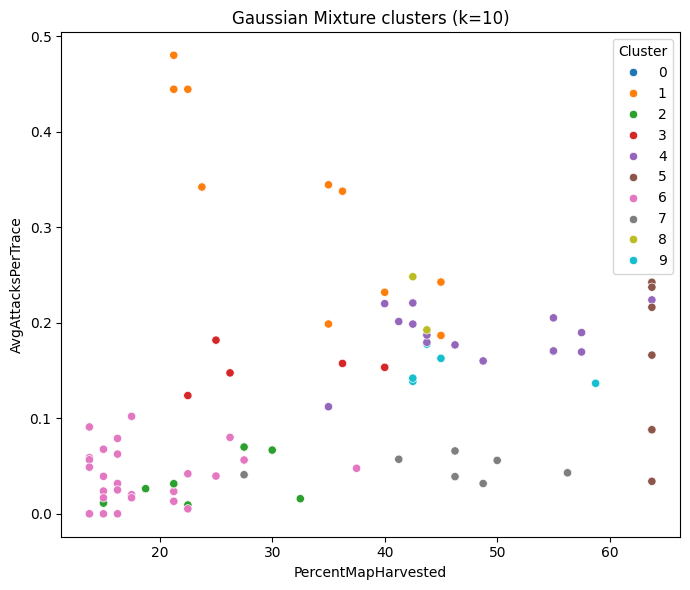

,FirstBarracks,NumBarracks,Light100,Heavy100,Ranged100,Light200,Heavy200,Ranged200,Light400,Heavy400,Ranged400,Light800,Heavy800,Ranged800,AvgDist100,AvgDist200,AvgDist400,AvgDist800,MaxAttacksSingleTrace,TimeMaxAttacks,TotalAttacks,AvgAttacksPerTrace,FirstAttackTime,TotalLight,TotalHeavy,TotalRanged,GameLength,PlayerWin,Workers100,Workers200,Workers400,Workers800,TotalWorkers,PercentMapHarvested,cluster
0,"530,00","1,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","1,00","0,00","0,00",11.068,11.068,11.068,10.901,"2,00","170,00","27,00",0.1627,"170,00","3,00","0,00","0,00","1058,00","1,00","3,00","5,00","9,00","16,00","17,00",45.00,9
1,"530,00","1,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","1,00","0,00","0,00",11.068,11.068,11.068,10.901,"2,00","170,00","27,00",0.1627,"170,00","3,00","0,00","0,00","1058,00","1,00","3,00","5,00","9,00","16,00","17,00",45.00,9
2,"530,00","1,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","1,00","0,00","0,00",9.499,9.499,9.499,9.771,"2,00","160,00","27,00",0.1776,"160,00","3,00","0,00","0,00","1009,00","1,00","3,00","5,00","9,00","16,00","17,00",43.75,9
3,"530,00","1,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","1,00","0,00","0,00",8.106,8.106,8.106,8.454,"2,00","150,00","32,00",0.1768,"150,00","4,00","0,00","0,00","1103,00","1,00","3,00","5,00","9,00","16,00","17,00",46.25,4
4,"530,00","1,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","0,00","1,00","0,00","0,00",6.978,6.978,6.978,7.431,"2,00","140,00","30,00",0.2013,"140,00","2,00","0,00","0,00","937,00","1,00","3,00","5,00","9,00","16,00","17,00",41.25,4



Cluster 0: row indices [54, 55, 56, 57]

Cluster 1: row indices [27, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79]

Cluster 2: row indices [23, 33, 39, 60, 61, 69, 80]

Cluster 3: row indices [50, 51, 52, 53, 58, 59]

Cluster 4: row indices [3, 4, 5, 6, 7, 8, 9, 12, 13, 14, 17, 18, 19, 26, 28]

Cluster 5: row indices [15, 16, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]

Cluster 6: row indices [24, 25, 34, 35, 36, 37, 38, 43, 45, 46, 47, 48, 62, 63, 64, 65, 66, 67, 68, 81, 82, 83, 84, 85, 86, 87, 88, 89]

Cluster 7: row indices [30, 31, 32, 40, 41, 42, 44, 49]

Cluster 8: row indices [20, 21]

Cluster 9: row indices [0, 1, 2, 10, 11, 22, 29]


,FirstBarracks,NumBarracks,Light100,Heavy100,Ranged100,Light200,Heavy200,Ranged200,Light400,Heavy400,Ranged400,Light800,Heavy800,Ranged800,AvgDist100,AvgDist200,AvgDist400,AvgDist800,MaxAttacksSingleTrace,TimeMaxAttacks,TotalAttacks,AvgAttacksPerTrace,FirstAttackTime,TotalLight,TotalHeavy,TotalRanged,GameLength,PlayerWin,Workers100,Workers200,Workers400,Workers800,TotalWorkers,PercentMapHarvested,cluster
23,300,2,0,0,0,0,0,0,0,0,1,0,0,0,9.085,8.767,9.706,9.706,1,170,13,0.0699,170,0,0,1,1710,0.5,2,4,5,5,5,27.50,2
33,390,1,0,0,0,0,0,0,0,0,0,0,0,0,9.295,9.345,9.327,9.327,1,240,2,0.0092,240,0,0,0,500,0,2,2,2,2,2,22.50,2
39,390,1,0,0,0,0,0,0,0,0,0,0,0,0,10.449,10.177,9.963,9.963,1,390,6,0.0158,390,0,0,0,605,0,2,2,4,4,5,32.50,2
60,670,1,0,0,0,0,0,0,0,0,0,1,0,0,11.522,11.053,11.212,11.154,1,350,9,0.0667,350,1,0,0,885,0,3,4,8,12,12,30.00,2
61,260,1,0,0,0,0,0,0,0,0,0,0,0,0,11.420,11.246,10.700,10.700,1,540,2,0.0263,540,0,0,0,640,0,2,2,4,4,5,18.75,2
69,310,1,0,0,0,0,0,0,0,0,0,0,1,0,9.916,9.937,10.381,10.630,1,200,7,0.0315,200,0,1,0,1355,0,2,3,4,5,5,21.25,2
80,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11.617,11.131,10.058,10.058,1,440,1,0.0112,440,0,0,0,535,0,3,4,7,7,7,15.00,2


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

%matplotlib inline

# 12x12-AllBotsvsWorkerDef.csv
df_raw = pd.read_csv("12x12-AllBotsvsWorkerDef.csv", sep=";", engine="python", header=0)

# Clean
df = df_raw.replace("None", pd.NA)
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.replace(",", ".", regex=False)

df_numeric = df.apply(pd.to_numeric, errors="coerce")
df_numeric = df_numeric.dropna(axis=1, how="all")   # drop non‑numeric columns

print("Numeric columns:", list(df_numeric.columns))

# Keep only rows that have at least one numeric value (but NOT drop them from df_raw)
valid_rows = df_numeric.dropna(axis=0, how="all")
print("Rows used for clustering:", len(valid_rows))

# Fill NaNs in those rows
valid_filled = valid_rows.fillna(valid_rows.mean(numeric_only=True))

# ----- SCALE FEATURES -----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(valid_filled)

# Put back into a DataFrame so we can edit specific columns (if needed)
X_df = pd.DataFrame(X_scaled, columns=valid_filled.columns, index=valid_filled.index)
X_features = X_df.values

# ===== Gaussian Mixture in place of K-Means =====
k = 10
gmm = GaussianMixture(n_components=k, random_state=0)
cluster_labels = gmm.fit_predict(X_features)

# Create a new column in df_raw, default -1, then fill only for valid_rows
df_raw["cluster"] = -1
df_raw.loc[valid_filled.index, "cluster"] = cluster_labels

# "Cluster centers" (means in scaled feature space)
centers = pd.DataFrame(gmm.means_, columns=valid_filled.columns)
print("\nGMM cluster means (scaled features):")
display(centers)

# Plot (use same valid rows) - pick any two features that exist
x_feature = "PercentMapHarvested"
y_feature = "AvgAttacksPerTrace"

if x_feature in valid_filled.columns and y_feature in valid_filled.columns:
    plt.figure(figsize=(7, 6))
    sns.scatterplot(
        x=valid_filled[x_feature],
        y=valid_filled[y_feature],
        hue=cluster_labels,
        palette="tab10"
    )
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f"Gaussian Mixture clusters (k={k})")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.show()
else:
    print(f"Cannot plot: {x_feature} or {y_feature} not in numeric columns.")

# Make a copy that includes cluster labels, but only for valid rows
clustered = df_raw.loc[valid_filled.index].copy()
clustered["cluster"] = cluster_labels

# 1) Quick view: first few rows with clusters
display(clustered.head())

# 2) Show indices belonging to each cluster
for c in sorted(clustered["cluster"].unique()):
    idx = clustered.index[clustered["cluster"] == c].tolist()
    print(f"\nCluster {c}: row indices {idx}")

# 3) Example: show full rows for cluster 2
cluster_id = 2
cluster_rows = clustered[clustered["cluster"] == cluster_id]

pd.set_option("display.max_rows", None)      # show all rows
pd.set_option("display.max_columns", None)   # show all columns

display(cluster_rows)


Numeric columns: ['FirstBarracks', 'NumBarracks', 'Light100', 'Heavy100', 'Ranged100', 'Light200', 'Heavy200', 'Ranged200', 'Light400', 'Heavy400', 'Ranged400', 'Light800', 'Heavy800', 'Ranged800', 'AvgDist100', 'AvgDist200', 'AvgDist400', 'AvgDist800', 'MaxAttacksSingleTrace', 'TimeMaxAttacks', 'TotalAttacks', 'AvgAttacksPerTrace', 'FirstAttackTime', 'TotalLight', 'TotalHeavy', 'TotalRanged', 'GameLength', 'PlayerWin', 'Workers100', 'Workers200', 'Workers400', 'Workers800', 'TotalWorkers', 'PercentMapHarvested']
Rows used for clustering: 100

Cluster sizes (Agglomerative):
agg_cluster
0    12
1     8
2    11
3    14
4    14
5     7
6    21
7     6
8     5
9     2
Name: count, dtype: int64

Cluster means for a few key features (Agglomerative):


,PercentMapHarvested,AvgAttacksPerTrace,FirstAttackTime,TotalWorkers
agg_cluster,,,,
0,63.750000,0.125992,145.000000,43.916667
1,45.468750,0.140838,176.250000,14.875000
2,31.477273,0.336118,260.909091,9.545455
3,49.464286,0.190907,142.857143,21.785714
4,19.821429,0.027993,226.428571,5.714286
5,49.285714,0.047900,287.142857,10.000000
6,16.964286,0.034776,148.095238,3.523810
7,31.666667,0.152850,416.000000,1.000000
8,29.500000,0.056400,160.000000,6.400000


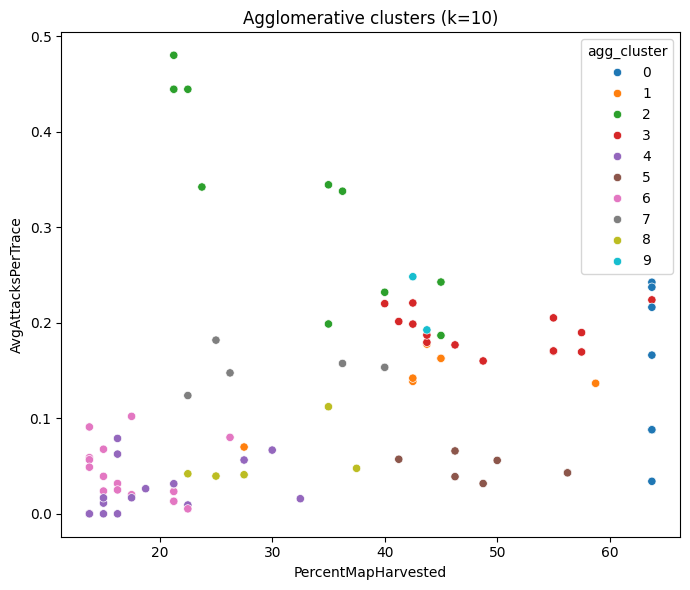


Rows in agg_cluster 2:


,FirstBarracks,NumBarracks,Light100,Heavy100,Ranged100,Light200,Heavy200,Ranged200,Light400,Heavy400,Ranged400,Light800,Heavy800,Ranged800,AvgDist100,AvgDist200,AvgDist400,AvgDist800,MaxAttacksSingleTrace,TimeMaxAttacks,TotalAttacks,AvgAttacksPerTrace,FirstAttackTime,TotalLight,TotalHeavy,TotalRanged,GameLength,PlayerWin,Workers100,Workers200,Workers400,Workers800,TotalWorkers,PercentMapHarvested,agg_cluster
27,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8.074,7.318,5.726,5.726,1,190,30,0.1987,190,0,0,0,528,1,2,4,7,7,10,35.00,2
70,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10.716,9.524,8.325,8.325,2,450,32,0.2319,400,0,0,0,676,1,3,5,9,9,14,40.00,2
71,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10.716,9.524,8.325,7.506,3,500,49,0.2426,400,0,0,0,876,1,3,5,9,17,18,45.00,2
72,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9.205,8.051,6.484,6.484,3,430,31,0.3444,390,0,0,0,530,1,3,5,9,9,11,35.00,2
73,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7.919,5.613,5.613,5.613,2,200,13,0.3421,160,0,0,0,260,1,3,5,5,5,6,23.75,2
74,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6.778,6.778,6.778,6.778,2,170,12,0.4444,140,0,0,0,195,1,3,3,3,3,4,21.25,2
75,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6.095,6.095,6.095,6.095,2,170,12,0.4444,140,0,0,0,195,1,3,3,3,3,4,21.25,2
76,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6.304,6.304,6.304,6.304,2,160,12,0.4800,130,0,0,0,190,1,3,3,3,3,4,21.25,2
77,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6.992,5.019,5.019,5.019,2,180,12,0.4444,150,0,0,0,210,1,3,5,5,5,5,22.50,2
78,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7.919,7.129,5.091,5.091,3,405,26,0.3377,370,0,0,0,540,1,3,5,9,9,11,36.25,2



Cluster members (row indices):

Cluster 0: row indices [15, 16, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]

Cluster 1: row indices [0, 1, 2, 10, 11, 22, 23, 29]

Cluster 2: row indices [27, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79]

Cluster 3: row indices [3, 4, 5, 6, 7, 8, 9, 12, 13, 14, 17, 18, 19, 28]

Cluster 4: row indices [24, 33, 39, 48, 60, 61, 62, 66, 69, 80, 81, 82, 88, 89]

Cluster 5: row indices [30, 31, 32, 40, 41, 42, 49]

Cluster 6: row indices [25, 34, 35, 36, 37, 38, 45, 54, 55, 56, 57, 63, 64, 65, 67, 68, 83, 84, 85, 86, 87]

Cluster 7: row indices [50, 51, 52, 53, 58, 59]

Cluster 8: row indices [26, 43, 44, 46, 47]

Cluster 9: row indices [20, 21]


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

%matplotlib inline

# ===== LOAD AND CLEAN =====
df_raw = pd.read_csv("12x12-AllBotsvsWorkerDef.csv", sep=";", engine="python", header=0)

# Replace "None" with NaN and fix decimal commas
df = df_raw.replace("None", pd.NA)
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.replace(",", ".", regex=False)

# Numeric-only version
df_numeric = df.apply(pd.to_numeric, errors="coerce")
df_numeric = df_numeric.dropna(axis=1, how="all")   # drop non-numeric columns

print("Numeric columns:", list(df_numeric.columns))

# Keep only rows that have at least one numeric value (for clustering)
valid_rows = df_numeric.dropna(axis=0, how="all")
print("Rows used for clustering:", len(valid_rows))

# Fill NaNs in those rows
valid_filled = valid_rows.fillna(valid_rows.mean(numeric_only=True))

# ===== SCALE FEATURES =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(valid_filled)

X_df = pd.DataFrame(X_scaled, columns=valid_filled.columns, index=valid_filled.index)
X_features = X_df.values

# ===== AGGLOMERATIVE CLUSTERING =====
k = 10
agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
agg_labels = agg.fit_predict(X_features)

# Attach labels back to original df_raw
df_raw["agg_cluster"] = -1
df_raw.loc[valid_filled.index, "agg_cluster"] = agg_labels

# DataFrame of only clustered rows (original + label)
clustered = df_raw.loc[valid_filled.index].copy()
clustered["agg_cluster"] = agg_labels

# ===== NUMERIC VIEW ALIGNED WITH CLUSTERS (FIX FOR groupby.mean) =====
numeric_with_clusters = df_numeric.loc[valid_filled.index].copy()
numeric_with_clusters["agg_cluster"] = agg_labels

print("\nCluster sizes (Agglomerative):")
print(numeric_with_clusters["agg_cluster"].value_counts().sort_index())

print("\nCluster means for a few key features (Agglomerative):")
cols_to_show = ["PercentMapHarvested", "AvgAttacksPerTrace",
                "FirstAttackTime", "TotalWorkers"]
display(
    numeric_with_clusters.groupby("agg_cluster")[cols_to_show].mean()
)

# ===== 2D PLOT =====
x_feature = "PercentMapHarvested"
y_feature = "AvgAttacksPerTrace"

if x_feature in valid_filled.columns and y_feature in valid_filled.columns:
    plt.figure(figsize=(7, 6))
    sns.scatterplot(
        x=valid_filled[x_feature],
        y=valid_filled[y_feature],
        hue=agg_labels,
        palette="tab10"
    )
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f"Agglomerative clusters (k={k})")
    plt.legend(title="agg_cluster")
    plt.tight_layout()
    plt.show()
else:
    print(f"Cannot plot: {x_feature} or {y_feature} not in numeric columns.")

# ===== SHOW ALL ROWS FOR ONE CLUSTER =====
cluster_id = 2  # pick any 0..k-1
cluster_rows = clustered[clustered["agg_cluster"] == cluster_id]

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

print(f"\nRows in agg_cluster {cluster_id}:")
display(cluster_rows)

print("\nCluster members (row indices):")
for c in sorted(numeric_with_clusters["agg_cluster"].unique()):
    idx = numeric_with_clusters.index[numeric_with_clusters["agg_cluster"] == c].tolist()
    print(f"\nCluster {c}: row indices {idx}")


In [32]:
import re
import numpy as np

cluster_text = """
Cluster 0: row indices [54, 55, 56, 57]

Cluster 1: row indices [27, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79]

Cluster 2: row indices [23, 33, 39, 60, 61, 69, 80]

Cluster 3: row indices [50, 51, 52, 53, 58, 59]

Cluster 4: row indices [3, 4, 5, 6, 7, 8, 9, 12, 13, 14, 17, 18, 19, 26, 28]

Cluster 5: row indices [15, 16, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]

Cluster 6: row indices [24, 25, 34, 35, 36, 37, 38, 43, 45, 46, 47, 48, 62, 63, 64, 65, 66, 67, 68, 81, 82, 83, 84, 85, 86, 87, 88, 89]

Cluster 7: row indices [30, 31, 32, 40, 41, 42, 44, 49]

Cluster 8: row indices [20, 21]

Cluster 9: row indices [0, 1, 2, 10, 11, 22, 29]
"""

# ---------- CONFIG ----------
bot_names = [
    "Aggrobot",          # 0–9
    "TMA",               # 10–19
    "ObiBotKenobi",      # 20–29
    "CoacAI",            # 30–39
    "mayari",            # 40–49
    "POLightRush",       # 50–59
    "RandomBiasedAI",    # 60–69
    "Tiamat",            # 70–79
    "TsuneBot",          # 80–89
    "WorkerRushPlusPlus" # 90–99
]

def true_cluster_id(idx: int) -> int:
    return idx // 10

# ---------- PARSE CLUSTER TEXT ----------
pattern = r"Cluster\s+(\d+):\s*row indices\s*\[([^\]]*)\]"
matches = re.findall(pattern, cluster_text)

clusters = {}  # predicted cluster_id -> list of indices
for cid_str, idx_str in matches:
    cid = int(cid_str)
    if idx_str.strip():
        indices = [int(x.strip()) for x in idx_str.split(",")]
    else:
        indices = []
    clusters[cid] = indices

# ---------- BUILD CONFUSION COUNTS ----------
n_pred = len(clusters)
n_true = len(bot_names)
conf = np.zeros((n_pred, n_true), dtype=int)  # conf[pred, true]

total_points = 0
for pred_cid, idxs in clusters.items():
    for i in idxs:
        t = true_cluster_id(i)
        if 0 <= t < n_true:
            conf[pred_cid, t] += 1
            total_points += 1

# ---------- GREEDY ONE-TO-ONE ASSIGNMENT ----------
assigned_true = {}   # pred_cid -> true_id
used_true_ids = set()

pairs = []
for p in range(n_pred):
    for t in range(n_true):
        if conf[p, t] > 0:
            pairs.append((conf[p, t], p, t))
pairs.sort(reverse=True)  # highest overlap first

for cnt, p, t in pairs:
    if p not in assigned_true and t not in used_true_ids:
        assigned_true[p] = t
        used_true_ids.add(t)

remaining_true = [t for t in range(n_true) if t not in used_true_ids]
for p in range(n_pred):
    if p not in assigned_true:
        if remaining_true:
            t = remaining_true.pop(0)
            assigned_true[p] = t
        else:
            assigned_true[p] = 0

# ---------- PER-CLUSTER REPORT ----------
total_correct = 0

print("Per-cluster accuracy with unique true labels:\n")

for cid in sorted(clusters.keys()):
    idxs = clusters[cid]
    size = len(idxs)
    if size == 0:
        print(f"Cluster {cid}: EMPTY")
        continue

    assigned_true_id = assigned_true[cid]
    correct = conf[cid, assigned_true_id]
    acc = correct / size
    bot_label = bot_names[assigned_true_id]
    total_correct += correct

    print(
        f"Cluster {cid}: size={size}, "
        f"assigned true cluster={assigned_true_id} ({bot_label}), "
        f"correct={correct}, accuracy={acc:.3f}"
    )

    # Breakdown of all true strategies in this cluster
    print("  Composition:")
    for t in range(n_true):
        count_t = conf[cid, t]
        if count_t > 0:
            print(f"    {bot_names[t]}: {count_t}")
    print()

overall_acc = total_correct / total_points if total_points > 0 else 0.0
print(f"Total accuracy: {total_correct}/{total_points} = {overall_acc:.3f}")


Per-cluster accuracy with unique true labels:

Cluster 0: size=4, assigned true cluster=1 (TMA), correct=0, accuracy=0.000
  Composition:
    POLightRush: 4

Cluster 1: size=11, assigned true cluster=7 (Tiamat), correct=10, accuracy=0.909
  Composition:
    ObiBotKenobi: 1
    Tiamat: 10

Cluster 2: size=7, assigned true cluster=6 (RandomBiasedAI), correct=3, accuracy=0.429
  Composition:
    ObiBotKenobi: 1
    CoacAI: 2
    RandomBiasedAI: 3
    TsuneBot: 1

Cluster 3: size=6, assigned true cluster=5 (POLightRush), correct=6, accuracy=1.000
  Composition:
    POLightRush: 6

Cluster 4: size=15, assigned true cluster=0 (Aggrobot), correct=7, accuracy=0.467
  Composition:
    Aggrobot: 7
    TMA: 6
    ObiBotKenobi: 2

Cluster 5: size=12, assigned true cluster=9 (WorkerRushPlusPlus), correct=10, accuracy=0.833
  Composition:
    TMA: 2
    WorkerRushPlusPlus: 10

Cluster 6: size=28, assigned true cluster=8 (TsuneBot), correct=9, accuracy=0.321
  Composition:
    ObiBotKenobi: 2
    Coa

Numeric columns: ['FirstBarracks', 'NumBarracks', 'Light100', 'Heavy100', 'Ranged100', 'Light200', 'Heavy200', 'Ranged200', 'Light400', 'Heavy400', 'Ranged400', 'Light800', 'Heavy800', 'Ranged800', 'AvgDist100', 'AvgDist200', 'AvgDist400', 'AvgDist800', 'MaxAttacksSingleTrace', 'TimeMaxAttacks', 'TotalAttacks', 'AvgAttacksPerTrace', 'FirstAttackTime', 'TotalLight', 'TotalHeavy', 'TotalRanged', 'GameLength', 'PlayerWin', 'Workers100', 'Workers200', 'Workers400', 'Workers800', 'TotalWorkers', 'PercentMapHarvested']
Rows used for clustering: 1100

Cluster sizes (Agglomerative):
agg_cluster
0     214
1      98
2     268
3      36
4     121
5      29
6     125
7      31
8      38
9      44
10     96
Name: count, dtype: int64

Cluster means for a few key features (Agglomerative):


,PercentMapHarvested,AvgAttacksPerTrace,FirstAttackTime,TotalWorkers
agg_cluster,,,,
0,27.464953,0.073711,287.350467,4.962617
1,32.908163,0.103591,372.551020,2.500000
2,26.665112,0.292116,181.679104,7.037313
3,54.548611,0.136333,240.277778,21.833333
4,44.204545,0.123323,182.727273,18.479339
5,39.267241,0.194703,238.965517,8.896552
6,17.000000,0.023260,140.320000,3.840000
7,63.750000,0.128784,145.161290,44.387097
8,48.190789,0.033589,337.684211,9.315789


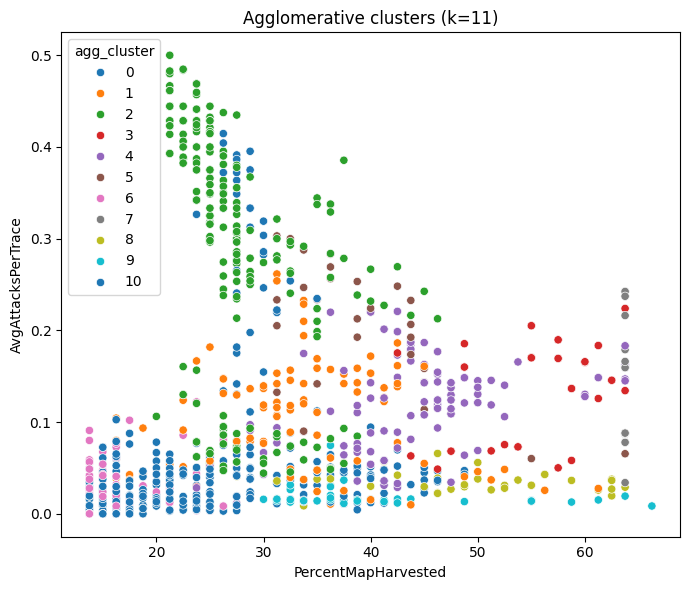


Cluster members (row indices):

Cluster 0: row indices [100, 101, 102, 109, 112, 113, 114, 117, 118, 119, 120, 121, 122, 129, 132, 136, 137, 139, 141, 143, 144, 145, 147, 148, 151, 152, 153, 154, 155, 157, 159, 160, 161, 162, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 183, 189, 190, 191, 192, 199, 200, 201, 202, 203, 204, 206, 207, 209, 222, 223, 226, 227, 229, 240, 241, 243, 245, 246, 248, 249, 262, 263, 267, 268, 269, 270, 271, 272, 273, 274, 276, 277, 278, 279, 283, 286, 287, 288, 290, 292, 293, 296, 297, 299, 306, 310, 311, 312, 313, 314, 318, 319, 330, 331, 332, 333, 336, 337, 343, 345, 346, 347, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 373, 384, 386, 393, 395, 397, 400, 401, 402, 403, 408, 409, 435, 436, 437, 474, 490, 491, 492, 493, 498, 499, 502, 507, 509, 510, 511, 512, 514, 521, 522, 527, 533, 534, 536, 537, 538, 539, 540, 550, 551, 553, 555, 556, 558, 560, 562, 566, 569, 581, 589, 590, 591, 592, 593, 599, 611, 612, 613, 614, 617, 619, 630, 631, 632, 633

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

%matplotlib inline

# ===== LOAD AND CLEAN =====
df_raw = pd.read_csv("12x12-ALL_bots_analysis.csv", sep=";", engine="python", header=0)

# Replace "None" with NaN and fix decimal commas
df = df_raw.replace("None", pd.NA)
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.replace(",", ".", regex=False)

# Numeric-only version
df_numeric = df.apply(pd.to_numeric, errors="coerce")
df_numeric = df_numeric.dropna(axis=1, how="all")   # drop non-numeric columns

print("Numeric columns:", list(df_numeric.columns))

# Keep only rows that have at least one numeric value (for clustering)
valid_rows = df_numeric.dropna(axis=0, how="all")
print("Rows used for clustering:", len(valid_rows))

# Fill NaNs in those rows
valid_filled = valid_rows.fillna(valid_rows.mean(numeric_only=True))

# ===== SCALE FEATURES =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(valid_filled)

X_df = pd.DataFrame(X_scaled, columns=valid_filled.columns, index=valid_filled.index)
X_features = X_df.values

# ===== AGGLOMERATIVE CLUSTERING =====
k = 11
agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
agg_labels = agg.fit_predict(X_features)

# Attach labels back to original df_raw
df_raw["agg_cluster"] = -1
df_raw.loc[valid_filled.index, "agg_cluster"] = agg_labels

# DataFrame of only clustered rows (original + label)
clustered = df_raw.loc[valid_filled.index].copy()
clustered["agg_cluster"] = agg_labels

# ===== NUMERIC VIEW ALIGNED WITH CLUSTERS (FIX FOR groupby.mean) =====
numeric_with_clusters = df_numeric.loc[valid_filled.index].copy()
numeric_with_clusters["agg_cluster"] = agg_labels

print("\nCluster sizes (Agglomerative):")
print(numeric_with_clusters["agg_cluster"].value_counts().sort_index())

print("\nCluster means for a few key features (Agglomerative):")
cols_to_show = ["PercentMapHarvested", "AvgAttacksPerTrace",
                "FirstAttackTime", "TotalWorkers"]
display(
    numeric_with_clusters.groupby("agg_cluster")[cols_to_show].mean()
)

# ===== 2D PLOT =====
x_feature = "PercentMapHarvested"
y_feature = "AvgAttacksPerTrace"

if x_feature in valid_filled.columns and y_feature in valid_filled.columns:
    plt.figure(figsize=(7, 6))
    sns.scatterplot(
        x=valid_filled[x_feature],
        y=valid_filled[y_feature],
        hue=agg_labels,
        palette="tab10"
    )
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f"Agglomerative clusters (k={k})")
    plt.legend(title="agg_cluster")
    plt.tight_layout()
    plt.show()
else:
    print(f"Cannot plot: {x_feature} or {y_feature} not in numeric columns.")

# ===== SHOW ALL ROWS FOR ONE CLUSTER =====
cluster_id = 2  # pick any 0..k-1
cluster_rows = clustered[clustered["agg_cluster"] == cluster_id]

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

#print(f"\nRows in agg_cluster {cluster_id}:")
#display(cluster_rows)

print("\nCluster members (row indices):")
for c in sorted(numeric_with_clusters["agg_cluster"].unique()):
    idx = numeric_with_clusters.index[numeric_with_clusters["agg_cluster"] == c].tolist()
    print(f"\nCluster {c}: row indices {idx}")


Numeric columns: ['FirstBarracks', 'NumBarracks', 'Light100', 'Heavy100', 'Ranged100', 'Light200', 'Heavy200', 'Ranged200', 'Light400', 'Heavy400', 'Ranged400', 'Light800', 'Heavy800', 'Ranged800', 'AvgDist100', 'AvgDist200', 'AvgDist400', 'AvgDist800', 'MaxAttacksSingleTrace', 'TimeMaxAttacks', 'TotalAttacks', 'AvgAttacksPerTrace', 'FirstAttackTime', 'TotalLight', 'TotalHeavy', 'TotalRanged', 'GameLength', 'PlayerWin', 'Workers100', 'Workers200', 'Workers400', 'Workers800', 'TotalWorkers', 'PercentMapHarvested']
Rows used for clustering: 1100
means = [np.float64(151.97272727272727), np.float64(0.4763636363636364), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.09090909090909091), np.float64(0.04), np.float64(0.026363636363636363), np.float64(0.14909090909090908), np.float64(0.11727272727272728), np.float64(0.03), np.float64(8.95147931382442), np.float64(8.2564001996008), np.float64(8.102299800796814), np.float64(8.009

,Cluster,NumGames,PercentGames
0,0,99,9.0
1,1,292,26.5
2,2,429,39.0
3,3,84,7.6
4,4,161,14.6
5,5,35,3.2



Cluster means for a few numeric features (KMeans):


,FirstBarracks,NumBarracks,Light100,Heavy100
kmeans_cluster,,,,
0,228.787879,1.090909,0.0,0.0
1,24.349315,0.078767,0.0,0.0
2,129.731935,0.435897,0.0,0.0
3,300.476190,1.000000,0.0,0.0
4,284.813665,0.434783,0.0,0.0
5,304.571429,1.485714,0.0,0.0


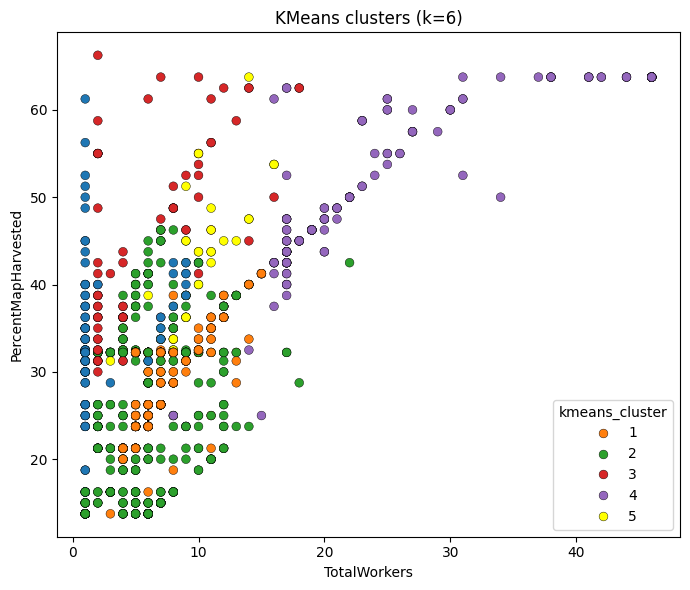


Centroids in scaled space (Z-scores):
                FirstBarracks  NumBarracks  Light100  Heavy100  Ranged100  \
kmeans_cluster                                                              
0                    0.369382     1.108012       0.0       0.0        0.0   
1                   -0.613704    -0.716858       0.0       0.0        0.0   
2                   -0.106950    -0.072960       0.0       0.0        0.0   
3                    0.714110     0.944105       0.0       0.0        0.0   
4                    0.638793    -0.074970       0.0       0.0        0.0   
5                    0.733803     1.819837       0.0       0.0        0.0   

                Light200  Heavy200  Ranged200  Light400  Heavy400  ...  \
kmeans_cluster                                                     ...   
0                    0.0       0.0        0.0  3.127141 -0.204124  ...   
1                    0.0       0.0        0.0 -0.304315 -0.204124  ...   
2                    0.0       0.0        0.0 -0

,cluster,bot_name,count,fraction
0,0,ObiBotKenobi,20,0.202020
1,0,PoLightRush,67,0.676768
2,0,RandomBiasedAI,1,0.010101
3,0,Tiamat,10,0.101010
4,0,TsuneBot,1,0.010101
5,1,Aggrobot,60,0.205479
6,1,ObiBotKenobi,20,0.068493
7,1,RandomBiasedAI,4,0.013699
8,1,TMA,52,0.178082
9,1,Tiamat,40,0.136986


,cluster,highest1_feature,highest1_delta,highest2_feature,highest2_delta,highest3_feature,highest3_delta,lowest1_feature,lowest1_delta,lowest2_feature,lowest2_delta,lowest3_feature,lowest3_delta
0,0,Light400,0.90,Light800,1.03,TotalLight,4.00,Workers100,-1.17,Workers200,-2.02,Workers400,-3.07
1,1,AvgAttacksPerTrace,0.15,Workers100,0.52,PlayerWin,0.38,AvgDist400,-1.86,AvgDist200,-1.84,AvgDist800,-1.76
2,2,AvgDist800,0.85,AvgDist400,0.74,AvgDist200,0.65,TotalAttacks,-9.13,PlayerWin,-0.35,PercentMapHarvested,-9.20
3,3,Heavy800,1.38,TotalHeavy,3.76,Heavy400,0.48,Workers200,-1.45,AvgAttacksPerTrace,-0.10,Workers400,-1.83
4,4,Workers800,9.24,TotalWorkers,16.44,PercentMapHarvested,19.13,FirstAttackTime,-62.18,Light400,-0.09,Heavy800,-0.11
5,5,Ranged800,0.91,Ranged400,0.80,TotalRanged,1.96,Workers100,-0.28,Heavy800,-0.12,Light400,-0.06


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans

%matplotlib inline

# ========= 0) LOAD AND CLEAN =========

df_raw = pd.read_csv("12x12-ALL_bots_analysis.csv", sep=";", engine="python", header=0)

# Replace "None" with NaN and fix decimal commas
df = df_raw.replace("None", pd.NA)
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.replace(",", ".", regex=False)

# Numeric-only version
df_numeric = df.apply(pd.to_numeric, errors="coerce")
df_numeric = df_numeric.dropna(axis=1, how="all")   # drop non-numeric columns

print("Numeric columns:", list(df_numeric.columns))

# Keep only rows that have at least one numeric value (for clustering)
valid_rows = df_numeric.dropna(axis=0, how="all")
print("Rows used for clustering:", len(valid_rows))

# Fill NaNs in those rows
valid_filled = valid_rows.fillna(valid_rows.mean(numeric_only=True))

# ========= 1) SCALE FEATURES =========

scaler = StandardScaler()
X_scaled = scaler.fit_transform(valid_filled)

joblib.dump(scaler, "scaler_agglomerative.joblib")  # save to disk [web:85]

X_df = pd.DataFrame(X_scaled, columns=valid_filled.columns, index=valid_filled.index)
X_features = X_df.values

means = scaler.mean_
scales = scaler.scale_

print("means =", list(means))
print("scales =", list(scales))

# ========= 2) K-MEANS CLUSTERING (CURRENT k) =========

k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_features)

# Attach labels back to original df_raw
df_raw["kmeans_cluster"] = -1
df_raw.loc[valid_filled.index, "kmeans_cluster"] = kmeans_labels

# DataFrame of only clustered rows (original + label)
clustered = df_raw.loc[valid_filled.index].copy()
clustered["kmeans_cluster"] = kmeans_labels

# NUMERIC VIEW ALIGNED WITH CLUSTERS
numeric_with_clusters = df_numeric.loc[valid_filled.index].copy()
numeric_with_clusters["kmeans_cluster"] = kmeans_labels

counts = numeric_with_clusters["kmeans_cluster"].value_counts().sort_index()
total = counts.sum()
perc = (counts / total * 100).round(1)

cluster_size_table = pd.DataFrame({
    "Cluster": counts.index,
    "NumGames": counts.values,
    "PercentGames": perc.values,
})

display(cluster_size_table) 

# Pick some existing columns to show cluster means for
all_num_cols = [c for c in numeric_with_clusters.columns if c != "kmeans_cluster"]
cols_to_show = all_num_cols[:4]  # first 4 numeric columns

if cols_to_show:
    print("\nCluster means for a few numeric features (KMeans):")
    display(
        numeric_with_clusters.groupby("kmeans_cluster")[cols_to_show].mean()
    )
else:
    print("No numeric feature columns to show.")

# ===== 2D PLOT (example) =====
if len(all_num_cols) >= 2:
    x_feature = all_num_cols[32]
    y_feature = all_num_cols[33]

    # high‑contrast palette for 6 clusters
    palette = sns.color_palette(
        ["#1f77b4",  # blue
         "#ff7f0e",  # orange
         "#2ca02c",  # green
         "#d62728",  # red
         "#9467bd",  # purple
         "#FFFF00"]  # yellow
    )

    plt.figure(figsize=(7, 6))
    sns.scatterplot(
        x=valid_filled[x_feature],
        y=valid_filled[y_feature],
        hue=kmeans_labels,
        palette=palette,
        s=40,        # slightly larger markers
        edgecolor="black",
        linewidth=0.3
    )
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f"KMeans clusters (k={k})")

    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=handles[1:], labels=labels[1:], title="kmeans_cluster")

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for a 2D plot.")

# ========= 3) FEATURE IMPORTANCE FOR CLUSTERS =========
# Using centroid variance in scaled space

X_with_labels = X_df.copy()
X_with_labels["kmeans_cluster"] = numeric_with_clusters["kmeans_cluster"].values

centroids = X_with_labels.groupby("kmeans_cluster").mean(numeric_only=True)
if "kmeans_cluster" in centroids.columns:
    centroids = centroids.drop(columns=["kmeans_cluster"])

print("\nCentroids in scaled space (Z-scores):")

centroids_df = pd.DataFrame(
    centroids,
    index=centroids.index,        # cluster IDs
    columns=centroids.columns     # feature names
)
centroids_df.to_csv("centroids.txt", sep=",", float_format="%.6f")

print(centroids)

feature_importance = centroids.var(axis=0).sort_values(ascending=False)

# === centroids in ORIGINAL feature space and save to file ===
centroids_scaled = centroids.values
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_original_df = pd.DataFrame(
    centroids_original,
    index=centroids.index,        # cluster IDs
    columns=centroids.columns     # feature names
)

# write to centroids.txt (CSV-style text)
# centroids_original_df.to_csv("centroids.txt", sep=",", float_format="%.6f")


print("\n=== Feature importance (centroid variance across clusters, higher = more discriminative) ===")
for feat, score in feature_importance.items():
    print(f"{feat:30s}  {score:.4f}")

#fi_df = feature_importance.reset_index()
#fi_df.columns = ["feature", "centroid_variance"]
#display(fi_df)

# ========= 4) CLUSTER COMPOSITION BY BOT TYPE =========
# Index ranges -> bot names (0-based indices)
# 0–99: Aggrobot
# 100–199: coac
# 200–299: mayari
# 300–399: ObiBotKenobi
# 400–499: PoLightRush
# 500–599: RandomBiasedAI
# 600–699: Tiamat
# 700–799: TMA
# 800–899: TsuneBot
# 900–999: workerDefense
# 1000–1099: workerRush

def bot_name_from_index(idx: int) -> str:
    if 0 <= idx <= 99:
        return "Aggrobot"
    elif 100 <= idx <= 199:
        return "coac"
    elif 200 <= idx <= 299:
        return "mayari"
    elif 300 <= idx <= 399:
        return "ObiBotKenobi"
    elif 400 <= idx <= 499:
        return "PoLightRush"
    elif 500 <= idx <= 599:
        return "RandomBiasedAI"
    elif 600 <= idx <= 699:
        return "Tiamat"
    elif 700 <= idx <= 799:
        return "TMA"
    elif 800 <= idx <= 899:
        return "TsuneBot"
    elif 900 <= idx <= 999:
        return "workerDefense"
    elif 1000 <= idx <= 1099:
        return "workerRush"
    else:
        return "UNKNOWN"

clustered_with_bots = numeric_with_clusters.copy()
clustered_with_bots["bot_name"] = clustered_with_bots.index.to_series().apply(bot_name_from_index)

print("\n=== Cluster composition by bot type ===")
all_clusters = sorted(clustered_with_bots["kmeans_cluster"].unique())
cluster_comp_list = []

for c in all_clusters:
    sub = clustered_with_bots[clustered_with_bots["kmeans_cluster"] == c]
    total_in_cluster = len(sub)
    bot_counts = sub["bot_name"].value_counts().sort_index()
    print(f"\nCluster {c}: total traces = {total_in_cluster}")
    for bot, count in bot_counts.items():
        print(f"  {bot:15s}: {count:4d}")
        cluster_comp_list.append({
            "cluster": c,
            "bot_name": bot,
            "count": count,
            "fraction": count / total_in_cluster
        })

cluster_comp_df = pd.DataFrame(cluster_comp_list)
display(cluster_comp_df.sort_values(["cluster", "bot_name"]))

# ========= 5) PER-CLUSTER DISTINCTIVE FEATURES (original space) =========

# numeric_with_clusters: all numeric features + 'kmeans_cluster'
X_raw = numeric_with_clusters.drop(columns=["kmeans_cluster"])
clusters = numeric_with_clusters["kmeans_cluster"]

# --- 1) standardise features (for ranking) ---
scaler = StandardScaler()
X_std = pd.DataFrame(
    scaler.fit_transform(X_raw),
    index=X_raw.index,
    columns=X_raw.columns,
)
X_std["kmeans_cluster"] = clusters

# std-space means and deviations
global_mean_std = X_std.drop(columns=["kmeans_cluster"]).mean(numeric_only=True)
cluster_means_std = X_std.groupby("kmeans_cluster").mean(numeric_only=True)
cluster_dev_std = cluster_means_std.subtract(global_mean_std, axis=1)

# --- 2) raw-space means and deviations (for reporting) ---
global_mean_raw = X_raw.mean(numeric_only=True)
cluster_means_raw = numeric_with_clusters.groupby("kmeans_cluster").mean(numeric_only=True)
cluster_dev_raw = cluster_means_raw.subtract(global_mean_raw, axis=1)

# --- 3) build wide table: top 3 high/low per cluster ---
TOP_N = 3
rows = []

for c in sorted(cluster_means_std.index):
    dev_std = cluster_dev_std.loc[c]   # for ranking
    dev_raw = cluster_dev_raw.loc[c]   # for deltas

    top_pos_feats = dev_std.sort_values(ascending=False).head(TOP_N).index
    top_neg_feats = dev_std.sort_values(ascending=True).head(TOP_N).index

    row = {"cluster": c}

    # highest (ranked in std, reported as raw)
    for rank, feat in enumerate(top_pos_feats, start=1):
        row[f"highest{rank}_feature"] = feat
        row[f"highest{rank}_delta"] = dev_raw[feat]

    # lowest
    for rank, feat in enumerate(top_neg_feats, start=1):
        row[f"lowest{rank}_feature"] = feat
        row[f"lowest{rank}_delta"] = dev_raw[feat]

    rows.append(row)

cluster_feature_wide = pd.DataFrame(rows)

# round deltas
delta_cols = [c for c in cluster_feature_wide.columns if c.endswith("_delta")]
cluster_feature_wide[delta_cols] = cluster_feature_wide[delta_cols].round(2)

cluster_feature_wide



,kmeans_cluster,bot_name,games,wins,win_rate
0,0,ObiBotKenobi,20,19.0,0.950
1,0,PoLightRush,67,36.0,0.537
2,0,RandomBiasedAI,1,0.0,0.000
3,0,Tiamat,10,3.0,0.300
4,0,TsuneBot,1,0.5,0.500
5,1,Aggrobot,60,58.0,0.967
6,1,ObiBotKenobi,20,20.0,1.000
7,1,RandomBiasedAI,4,0.0,0.000
8,1,TMA,52,50.0,0.962
9,1,Tiamat,40,39.0,0.975


kmeans_cluster,0,1,2,3,4,5
bot_name,,,,,,
Aggrobot,NaN,0.967,0.429,NaN,0.848,NaN
ObiBotKenobi,0.950,1.000,0.593,NaN,0.750,0.887
PoLightRush,0.537,NaN,0.000,NaN,NaN,NaN
RandomBiasedAI,0.000,0.000,0.011,NaN,0.786,NaN
TMA,NaN,0.962,0.857,NaN,0.703,1.000
Tiamat,0.300,0.975,0.242,0.929,0.667,NaN
TsuneBot,0.500,0.333,0.000,NaN,0.500,NaN
coac,NaN,NaN,0.231,0.818,NaN,NaN
mayari,NaN,1.000,0.608,0.917,NaN,NaN


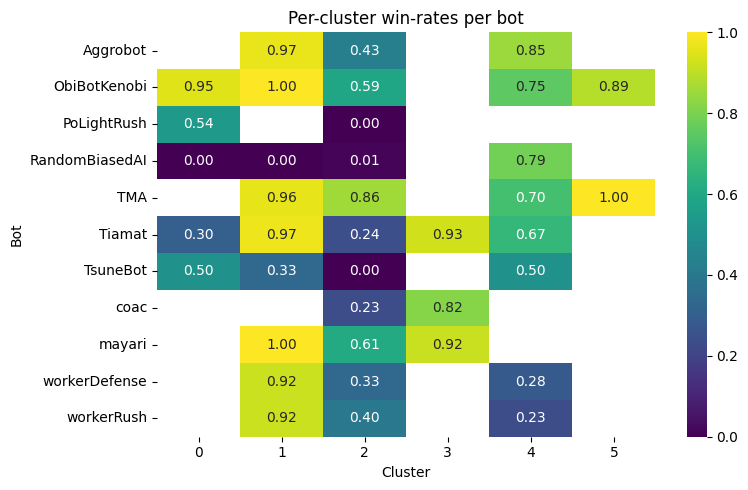

In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ========= 6) PER-BOT DISTINCTIVE FEATURES (original space) =========

# Start from the numeric data used for clustering (no cluster column)
base_numeric = df_numeric.loc[valid_filled.index].copy()

# Map each row index to a bot name (reusing your helper)
bot_labels = base_numeric.index.to_series().apply(bot_name_from_index)
base_numeric["bot_name"] = bot_labels

# --- 1) Build standardised version (for ranking by distinctiveness) ---

X_raw = base_numeric.drop(columns=["bot_name"])
scaler = StandardScaler()
X_std = pd.DataFrame(
    scaler.fit_transform(X_raw),
    index=X_raw.index,
    columns=X_raw.columns,
)
X_std["bot_name"] = base_numeric["bot_name"]

# Global mean in std space (should be ~0, but keep for completeness)
global_mean_std = X_std.drop(columns=["bot_name"]).mean(numeric_only=True)

# Per-bot means in std space
bot_means_std = X_std.groupby("bot_name").mean(numeric_only=True)

# Deviation of each bot's mean from global mean in std (z-score deltas)
bot_deviation_std = bot_means_std.subtract(global_mean_std, axis=1)

# --- 2) Compute raw-space means and deviations (for reporting) ---

# Global mean in raw space
global_mean_raw = X_raw.mean(numeric_only=True)

# Per-bot means in raw space
bot_means_raw = base_numeric.groupby("bot_name").mean(numeric_only=True)

# Raw deviation = per-bot mean - global mean
bot_deviation_raw = bot_means_raw.subtract(global_mean_raw, axis=1)

# --- 3) Pick top features per bot using std deviations, but store raw deltas ---

TOP_N = 3
rows = []

for bot in sorted(bot_means_std.index):
    dev_std = bot_deviation_std.loc[bot]       # for ranking
    dev_raw = bot_deviation_raw.loc[bot]       # for reporting

    # Top-N above and below in std space
    top_pos_feats = dev_std.sort_values(ascending=False).head(TOP_N).index
    top_neg_feats = dev_std.sort_values(ascending=True).head(TOP_N).index

    row = {"bot": bot}

    # highest features (std-based selection, raw delta reported)
    for rank, feat in enumerate(top_pos_feats, start=1):
        row[f"highest{rank}_feature"] = feat
        row[f"highest{rank}_delta"] = dev_raw[feat]

    # lowest features
    for rank, feat in enumerate(top_neg_feats, start=1):
        row[f"lowest{rank}_feature"] = feat
        row[f"lowest{rank}_delta"] = dev_raw[feat]

    rows.append(row)

bot_feature_wide = pd.DataFrame(rows)

# Round numeric deltas for readability
delta_cols = [c for c in bot_feature_wide.columns if c.endswith("_delta")]
bot_feature_wide[delta_cols] = bot_feature_wide[delta_cols].round(2)

bot_feature_wide

# ========= 6) PER-CLUSTER WIN-RATES PER BOT =========

# We assume df_raw has:
# - a 'kmeans_cluster' column (already attached above)
# - a 'winner' column with the index of the winning bot (e.g. 0/1 or bot name)
# - a 'bot_name' column for the bot that played this trace (build it if needed)

# If needed, map indices to bot names again for df_raw rows:
if "bot_name" not in df_raw.columns:
    df_raw["bot_name"] = df_raw.index.to_series().apply(bot_name_from_index)

# Filter to clustered rows only
perf = df_raw.loc[valid_filled.index].copy()

# Example: if you have a boolean / flag column 'PlayerWin' (1 = this bot won, 0 = lost)
# adapt this line to your actual win indicator:
win_col = "PlayerWin"   # change if your column is named differently

# Sanity check: drop rows without cluster or bot_name
perf = perf[(perf["kmeans_cluster"] != -1) & perf["bot_name"].notna()]

# Group by cluster and bot, compute games and win-rate
grouped = perf.groupby(["kmeans_cluster", "bot_name"])

perf_stats = grouped[win_col].agg(
    games="count",
    wins="sum",
)
perf_stats["win_rate"] = (perf_stats["wins"] / perf_stats["games"]).round(3)

# Reset index for a neat table
perf_stats = perf_stats.reset_index()

# Pivot to bot x cluster win-rate matrix for heatmap / tables
winrate_pivot = perf_stats.pivot(
    index="bot_name",
    columns="kmeans_cluster",
    values="win_rate"
)

display(perf_stats)      # long form: cluster, bot, games, wins, win_rate
display(winrate_pivot)   # matrix form: rows = bots, cols = clusters

# Optional: quick heatmap of per-cluster win-rates
plt.figure(figsize=(8, 5))
sns.heatmap(
    winrate_pivot,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0
)
plt.title("Per-cluster win-rates per bot")
plt.ylabel("Bot")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()

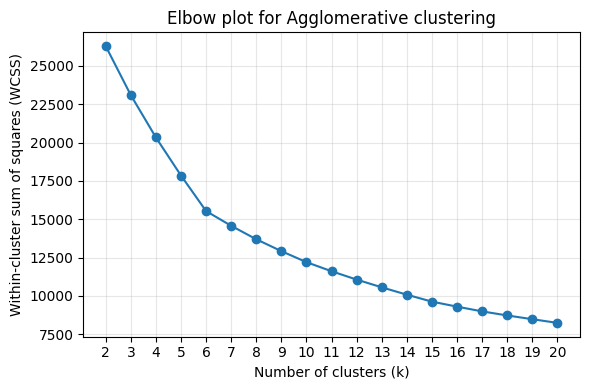

In [7]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import matplotlib.pyplot as plt

# ==== ELBOW METHOD FOR AGGLOMERATIVE (WCSS) ONLY ====

def compute_wcss(X, labels):
    wcss = 0.0
    for cl in np.unique(labels):
        Xk = X[labels == cl]
        if len(Xk) == 0:
            continue
        center = Xk.mean(axis=0)
        wcss += ((Xk - center) ** 2).sum()
    return wcss

k_values = range(2, 21)   # choose k range as needed
wcss_list = []

for k_tmp in k_values:
    agg_tmp = AgglomerativeClustering(n_clusters=k_tmp, linkage="ward")
    labels_tmp = agg_tmp.fit_predict(X_scaled)
    wcss_k = compute_wcss(X_scaled, labels_tmp)
    wcss_list.append(wcss_k)

plt.figure(figsize=(6, 4))
plt.plot(k_values, wcss_list, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-cluster sum of squares (WCSS)")
plt.title("Elbow plot for Agglomerative clustering")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



=== Cluster 0 ===
Total traces in cluster: 99

Per-bot composition and best direct counter(s):
  Bot type: ObiBotKenobi    (rows:  20) -> best vs this bot: TMA ( 50.0%)
  Bot type: PoLightRush     (rows:  67) -> best vs this bot: Aggrobot, TMA, ObiBotKenobi, WorkerRushPlusPlus (100.0%)
  Bot type: RandomBiasedAI  (rows:   1) -> best vs this bot: Aggrobot, Tiamat, CoacAI, TMA, mayari, ObiBotKenobi, WorkerRushPlusPlus, POLightRush, WorkerDefense (100.0%)
  Bot type: Tiamat          (rows:  10) -> best vs this bot: Aggrobot, TMA, ObiBotKenobi, WorkerRushPlusPlus (100.0%)
  Bot type: TsuneBot        (rows:   1) -> best vs this bot: Aggrobot, Tiamat, CoacAI, TMA, mayari, ObiBotKenobi, WorkerRushPlusPlus, WorkerDefense (100.0%)

Top 3 bots vs MIX of bots in this cluster (self-play included, weighted by counts):

  TMA               :  89.9% avg winrate vs bots in cluster 0
    vs ObiBotKenobi      :  50.0%
    vs POLightRush       : 100.0%
    vs RandomBiasedAI    : 100.0%
    vs Tiamat    

,bot,global_weighted_wr
0,Aggrobot,83.181818
3,TMA,81.363636
6,ObiBotKenobi,79.545455
4,mayari,66.363636
7,WorkerRushPlusPlus,58.636364
9,WorkerDefense,49.545455
2,CoacAI,35.000000
1,Tiamat,33.636364
8,POLightRush,32.727273
10,RandomBiasedAI,10.909091


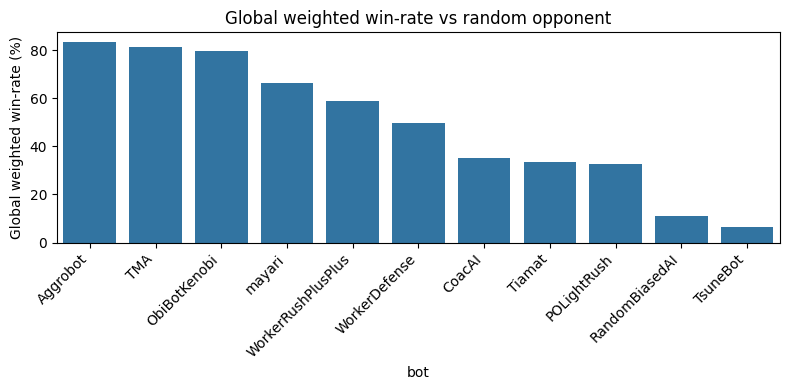

,cluster,bestbot1,percentile1,bestbot2,percentile2,bestbot3,percentile3
0,0,TMA,89.9,ObiBotKenobi,89.9,Aggrobot,86.9
1,1,Aggrobot,79.8,TMA,69.4,ObiBotKenobi,68.0
2,2,TMA,92.9,ObiBotKenobi,91.7,Aggrobot,89.8
3,3,TMA,91.4,ObiBotKenobi,85.7,Aggrobot,77.1
4,4,Aggrobot,82.0,TMA,68.8,ObiBotKenobi,65.0
5,5,TMA,50.0,ObiBotKenobi,50.0,Aggrobot,39.0


In [9]:
# ========= 6) WINRATE TABLE & CLUSTER COMPOSITION WITH COUNTERS =========

win_bots = [
    "Aggrobot",
    "Tiamat",
    "CoacAI",
    "TMA",
    "mayari",
    "TsuneBot",
    "ObiBotKenobi",
    "WorkerRushPlusPlus",
    "POLightRush",
    "WorkerDefense",
    "RandomBiasedAI",
]

# entries are games out of 20; diagonal is self‑play, set to 10 (~50% winrate)
win_data = [
    # vs:   Aggrobot Tiamat CoacAI TMA  mayari TsuneBot ObiBotKenobi WorkerRushPlusPlus POLightRush WorkerDefense RandomBiasedAI
    [10,    20,     20,    14,  12,   20,      7,            20,              20,           20,           20],  # Aggrobot
    [ 0,    10,     11,     0,   1,   20,      0,             0,               9,            3,           20],  # Tiamat
    [ 0,     9,    10,      0,   0,   20,      0,             0,              15,            3,           20],  # CoacAI
    [ 6,    20,     20,    10,  17,   20,     10,            18,              20,           18,           20],  # TMA
    [ 8,    19,     20,     3,  10,   20,      5,             9,              19,           13,           20],  # mayari
    [ 0,     0,      0,     0,   0,   10,      0,             0,               1,            0,            3],  # TsuneBot
    [13,    20,     20,    10,  15,   20,     10,            14,              20,           13,           20],  # ObiBotKenobi
    [ 0,    20,     20,     0,  11,   20,      6,            10,              20,            2,           20],  # WorkerRushPlusPlus
    [ 0,    11,      5,     0,   1,   18,      0,             0,              10,            7,           20],  # POLightRush
    [ 0,    17,     17,     0,   7,   20,      5,             0,              13,           10,           20],  # WorkerDefense
    [ 0,     0,      0,     0,   0,   14,      0,             0,               0,            0,           10],  # RandomBiasedAI
]

win_df = pd.DataFrame(win_data, index=win_bots, columns=win_bots) / 20.0

name_map = {
    "Aggrobot": "Aggrobot",
    "Tiamat": "Tiamat",
    "coac": "CoacAI",
    "CoacAI": "CoacAI",
    "TMA": "TMA",
    "mayari": "mayari",
    "Mayari": "mayari",
    "TsuneBot": "TsuneBot",
    "ObiBotKenobi": "ObiBotKenobi",
    "workerRush": "WorkerRushPlusPlus",
    "WorkerRushPlusPlus": "WorkerRushPlusPlus",
    "PoLightRush": "POLightRush",
    "POLightRush": "POLightRush",
    "workerDefense": "WorkerDefense",
    "WorkerDefense": "WorkerDefense",
    "RandomBiasedAI": "RandomBiasedAI",
}

cluster_comp_df2 = cluster_comp_df.copy()
cluster_comp_df2["win_name"] = cluster_comp_df2["bot_name"].map(name_map)
cluster_comp_df2 = cluster_comp_df2[cluster_comp_df2["win_name"].isin(win_df.index)]


def print_cluster_composition_with_counters(cluster_comp_df, win_df, top_n_global=3):
    """
    For each cluster:
      - list bot types present and counts
      - for each bot type: all best direct counter bots + winrate (%), ignoring self-play
      - top N bots vs the mixture of bots in this cluster (weighted by counts, self-play included)
      - for those top N, print full per-opponent winrates vs every bot type in the cluster.
    """
    for c in sorted(cluster_comp_df["cluster"].unique()):
        sub = cluster_comp_df[cluster_comp_df["cluster"] == c]

        print(f"\n=== Cluster {c} ===")
        print(f"Total traces in cluster: {sub['count'].sum()}")

        # Detailed per-bot counts
        bot_counts = sub.groupby(["bot_name", "win_name"])["count"].sum().reset_index()
        # Aggregated counts per canonical bot name for weighting
        winname_counts = bot_counts.groupby("win_name")["count"].sum()
        cluster_win_names = winname_counts.index.tolist()

        print("\nPer-bot composition and best direct counter(s):")
        for _, row in bot_counts.iterrows():
            bot_label = row["bot_name"]
            win_name = row["win_name"]
            cnt = row["count"]

            # direct counters: drop self-play
            col = win_df[win_name].drop(index=win_name)
            max_wr = col.max()
            best_attackers = col[col == max_wr].index.tolist()
            max_wr_pct = max_wr * 100.0

            best_str = ", ".join(best_attackers)
            print(
                f"  Bot type: {bot_label:15s} (rows: {cnt:3d}) "
                f"-> best vs this bot: {best_str} ({max_wr_pct:5.1f}%)"
            )

        print(f"\nTop {top_n_global} bots vs MIX of bots in this cluster "
              f"(self-play included, weighted by counts):")
        cluster_scores = []

        for attacker in win_df.index:
            wrs = []
            weights = []
            for opp_name, cnt in winname_counts.items():
                wr = win_df.loc[attacker, opp_name]  # include self-play
                wrs.append(wr)
                weights.append(cnt)
            if not wrs:
                continue
            mean_wr = np.average(wrs, weights=weights) * 100.0
            cluster_scores.append((attacker, mean_wr))

        cluster_scores.sort(key=lambda x: x[1], reverse=True)
        top_attackers = cluster_scores[:top_n_global]

        for attacker, mean_wr in top_attackers:
            print(f"\n  {attacker:18s}: {mean_wr:5.1f}% avg winrate vs bots in cluster {c}")
            # full row vs each bot type in this cluster
            row_vals = win_df.loc[attacker, cluster_win_names] * 100.0
            for opp_name, wr in row_vals.items():
                print(f"    vs {opp_name:18s}: {wr:5.1f}%")

# Run the detailed report
print_cluster_composition_with_counters(cluster_comp_df2, win_df, top_n_global=3)


def print_global_weighted_winrates(cluster_comp_df, win_df):
    """
    Overall weighted winrate for each bot vs a random opponent drawn
    from all clusters (weighted by counts, self-play included).
    """
    # Total counts per canonical bot name across all clusters
    winname_counts_global = (
        cluster_comp_df
        .groupby("win_name")["count"]
        .sum()
    )

    total_traces = winname_counts_global.sum()
    print(f"\n=== Global weighted winrates vs random opponent (total traces = {total_traces}) ===")

    results = []
    for attacker in win_df.index:
        wrs = []
        weights = []
        for opp_name, cnt in winname_counts_global.items():
            wr = win_df.loc[attacker, opp_name]  # include self-play
            wrs.append(wr)
            weights.append(cnt)
        if not wrs:
            continue
        mean_wr = np.average(wrs, weights=weights) * 100.0
        results.append((attacker, mean_wr))

    # Sort from best to worst
    results.sort(key=lambda x: x[1], reverse=True)
    for bot, wr in results:
        print(f"  {bot:18s}: {wr:5.1f}%")

# Call with cluster_comp_df2 (which has win_name + counts)
print_global_weighted_winrates(cluster_comp_df2, win_df)

#Here you can see that tsune bot is 6.4 which is the 50% wr agaisnt itself + 20% from other games by 11
def global_weighted_winrates_df(cluster_comp_df, win_df):
    winname_counts_global = (
        cluster_comp_df
        .groupby("win_name")["count"]
        .sum()
    )

    results = []
    for attacker in win_df.index:
        wrs = []
        weights = []
        for opp_name, cnt in winname_counts_global.items():
            wr = win_df.loc[attacker, opp_name]  # include self-play
            wrs.append(wr)
            weights.append(cnt)
        if not wrs:
            continue
        mean_wr = np.average(wrs, weights=weights) * 100.0
        results.append((attacker, mean_wr))

    df_wr = pd.DataFrame(results, columns=["bot", "global_weighted_wr"])
    df_wr = df_wr.sort_values("global_weighted_wr", ascending=False)
    return df_wr

global_wr_df = global_weighted_winrates_df(cluster_comp_df2, win_df)
display(global_wr_df)

# Bar plot
plt.figure(figsize=(8, 4))
sns.barplot(
    data=global_wr_df,
    x="bot",
    y="global_weighted_wr",
    color="#1f77b4"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Global weighted win-rate (%)")
plt.title("Global weighted win-rate vs random opponent")
plt.tight_layout()
plt.show()

def per_cluster_top_attackers_wide(cluster_comp_df, win_df, top_n=3):
    rows = []
    for c in sorted(cluster_comp_df["cluster"].unique()):
        sub = cluster_comp_df[cluster_comp_df["cluster"] == c]

        bot_counts = sub.groupby(["bot_name", "win_name"])["count"].sum().reset_index()
        winname_counts = bot_counts.groupby("win_name")["count"].sum()
        if winname_counts.empty:
            continue

        cluster_scores = []
        for attacker in win_df.index:
            wrs = []
            weights = []
            for opp_name, cnt in winname_counts.items():
                wr = win_df.loc[attacker, opp_name]  # include self-play
                wrs.append(wr)
                weights.append(cnt)
            if not wrs:
                continue
            mean_wr = np.average(wrs, weights=weights) * 100.0
            cluster_scores.append((attacker, mean_wr))

        cluster_scores.sort(key=lambda x: x[1], reverse=True)
        top_attackers = cluster_scores[:top_n]

        row = {"cluster": c}
        for rank, (attacker, mean_wr) in enumerate(top_attackers, start=1):
            row[f"bestbot{rank}"] = attacker
            row[f"percentile{rank}"] = round(mean_wr, 1)

        rows.append(row)

    return pd.DataFrame(rows).sort_values("cluster")

per_cluster_top_wide = per_cluster_top_attackers_wide(cluster_comp_df2, win_df, top_n=3)
display(per_cluster_top_wide)


In [29]:
import re
from pathlib import Path

BASE_DIR = Path(r"C:\Users\bikep\IdeaProjects\myMicroRTSBot\traces\outputFolder")

game_start_re = re.compile(r"^Assigned cluster: (\d+) at time : (\d+)")
game_over_re = re.compile(r"^Game over!  Winner: ([\-0-9]+) in (\d+) cycles")

def parse_games(lines):
    games = []
    current = {"clusters": [], "times": []}

    for line in lines:
        line = line.strip()
        if not line:
            continue

        m_start = game_start_re.match(line)
        if m_start:
            c = int(m_start.group(1))
            t = int(m_start.group(2))
            current["clusters"].append(c)
            current["times"].append(t)
            continue

        m_over = game_over_re.match(line)
        if m_over:
            winner = int(m_over.group(1))
            cycles = int(m_over.group(2))
            current["winner"] = winner
            current["cycles"] = cycles
            games.append(current)
            current = {"clusters": [], "times": []}

    return games

def main():
    all_games = []
    # match all output_*.txt, but skip names containing 'asPlayer1_'
    for path in BASE_DIR.glob("output_*.txt"):
       # if "asPlayer1_" in path.name:
       #     continue
        if "myBot" in path.name:
            continue
        text = path.read_text(encoding="utf-8")
        games = parse_games(text.splitlines())
        for g in games:
            g["file"] = path.name
        all_games.extend(games)

    # CSV header
    print("idx,file,clusters,times,winner,cycles")
    for i, g in enumerate(all_games, start=1):
        clusters_str = " ".join(str(c) for c in g["clusters"])
        times_str = " ".join(str(t) for t in g["times"])
        print(f'{i},{g["file"]},"{clusters_str}","{times_str}",{g.get("winner","")},{g.get("cycles","")}')

# run it in Jupyter:
main()


idx,file,clusters,times,winner,cycles
1,output_AggrobotAStarPathFinding.txt,"2 0 2 1","51 131 411 571",0,1045
2,output_AggrobotAStarPathFinding.txt,"2 0 2 1","51 131 411 571",0,1045
3,output_AggrobotAStarPathFinding.txt,"2 0 1","51 131 571",0,1158
4,output_AggrobotAStarPathFinding.txt,"2 0 2 1","51 131 211 571",-1,5000
5,output_AggrobotAStarPathFinding.txt,"2 0 2 1","51 131 171 691",0,1649
6,output_AggrobotAStarPathFinding.txt,"2 0 2 1","51 131 171 771",0,1160
7,output_AggrobotAStarPathFinding.txt,"2 0 2 1","51 131 171 811",0,1243
8,output_AggrobotAStarPathFinding.txt,"2 0 2 1","51 131 171 691",0,1054
9,output_AggrobotAStarPathFinding.txt,"2 0 2 0 1","51 131 291 571 651",0,1304
10,output_AggrobotAStarPathFinding.txt,"2 0 2 0 1","51 131 491 571 651",1,1310
11,output_asPlayer1_AggrobotAStarPathFinding.txt,"2 0 1","51 131 811",0,1782
12,output_asPlayer1_AggrobotAStarPathFinding.txt,"2 0 1","51 131 811",0,1782
13,output_asPlayer1_AggrobotAStarPathFinding.txt,"2 0 2 1","51 131 491 611",1,10

In [28]:
import re
from pathlib import Path
from collections import defaultdict
import pandas as pd

BASE_DIR = Path(r"C:\Users\bikep\IdeaProjects\myMicroRTSBot\traces\\outputFolder")

game_start_re = re.compile(r"^Assigned cluster: (\d+) at time : (\d+)")
game_over_re  = re.compile(r"^Game over!\s+Winner:\s*(-?\d+)\s+in\s+(\d+)\s+cycles")

def parse_games(lines):
    games = []
    current = {"clusters": [], "times": []}
    for line in lines:
        line = line.strip()
        if not line:
            continue
        m_start = game_start_re.match(line)
        if m_start:
            current["clusters"].append(int(m_start.group(1)))
            current["times"].append(int(m_start.group(2)))
            continue
        m_over = game_over_re.match(line)
        if m_over:
            current["winner"] = int(m_over.group(1))
            current["cycles"] = int(m_over.group(2))
            games.append(current)
            current = {"clusters": [], "times": []}
    return games

def canonical_opponent(path: Path) -> str:
    """
    output_asPlayer1_ObiBotKenobi.txt  -> ObiBotKenobi
    output_ObiBotKenobi.txt            -> ObiBotKenobi
    output_MyBot_asPlayer1_mayari.txt  -> mayari
    """
    name = path.name
    if name.startswith("output_"):
        name = name[len("output_"):]
    if name.endswith(".txt"):
        name = name[:-4]
    marker = "_asPlayer1_"
    pos = name.find(marker)
    if pos != -1:
        # opponent is AFTER _asPlayer1_
        return name[pos + len(marker):]
    # no marker: strip leading asPlayer1 just in case
    if name.startswith("asPlayer1_"):
        return name[len("asPlayer1_"):]
    return name

def is_player1_file(path: Path) -> bool:
    return "_asPlayer1_" in path.name or path.name.startswith("output_asPlayer1_")

# raw stats keyed by canonical opponent, per side
p0_stats = defaultdict(lambda: {"games": 0, "wins": 0, "ties": 0, "losses": 0})
p1_stats = defaultdict(lambda: {"games": 0, "wins": 0, "ties": 0, "losses": 0})

for path in BASE_DIR.glob("output_*.txt"):
    if "myBot" in path.name:
        continue

    opp = canonical_opponent(path)
    text = path.read_text(encoding="utf-8")
    games = parse_games(text.splitlines())

    if is_player1_file(path):
        # our bot is player 1 → we win if winner == 0
        for g in games:
            w = g["winner"]
            p1_stats[opp]["games"] += 1
            if w == 0:
                p1_stats[opp]["wins"] += 1
            elif w == -1:
                p1_stats[opp]["ties"] += 1
            else:
                p1_stats[opp]["losses"] += 1
    else:
        # our bot is player 0 → we win if winner == 1
        for g in games:
            w = g["winner"]
            p0_stats[opp]["games"] += 1
            if w == 1:
                p0_stats[opp]["wins"] += 1
            elif w == -1:
                p0_stats[opp]["ties"] += 1
            else:
                p0_stats[opp]["losses"] += 1

def side_df(stats_dict, label):
    rows = []
    total_g = total_w = total_t = total_l = 0
    for opp, s in stats_dict.items():
        g = s["games"]
        if g == 0:
            continue
        w = s["wins"]; t = s["ties"]; l = s["losses"]
        total_g += g; total_w += w; total_t += t; total_l += l
        rows.append({
            "opponent": opp,
            "games": g,
            "wins": w,
            "ties": t,
            "losses": l,
            "winrate": w / g,
        })
    df = pd.DataFrame(rows).sort_values("winrate", ascending=False)
    global_row = pd.DataFrame([{
        "opponent": f"GLOBAL_{label}",
        "games": total_g,
        "wins": total_w,
        "ties": total_t,
        "losses": total_l,
        "winrate": total_w / total_g if total_g else 0.0,
    }])
    return pd.concat([df, global_row], ignore_index=True)

df_p0 = side_df(p0_stats, "P0")
df_p1 = side_df(p1_stats, "P1")

# combined total: directly from raw stats dicts (avoids double counting)
all_opps = sorted(set(p0_stats.keys()) | set(p1_stats.keys()))
total_rows = []
total_g = total_w = total_t = total_l = 0

for opp in all_opps:
    s0 = p0_stats[opp]
    s1 = p1_stats[opp]
    g = s0["games"] + s1["games"]
    w = s0["wins"]  + s1["wins"]
    t = s0["ties"]  + s1["ties"]
    l = s0["losses"]+ s1["losses"]
    total_g += g; total_w += w; total_t += t; total_l += l
    total_rows.append({
        "opponent": opp,
        "games": g,
        "wins": w,
        "ties": t,
        "losses": l,
        "winrate": w / g if g else 0.0,
    })

global_row = pd.DataFrame([{
    "opponent": "GLOBAL_TOTAL",
    "games": total_g,
    "wins": total_w,
    "ties": total_t,
    "losses": total_l,
    "winrate": total_w / total_g if total_g else 0.0,
}])
df_total = pd.concat(
    [pd.DataFrame(total_rows).sort_values("winrate", ascending=False), global_row],
    ignore_index=True
)

print("=== Our bot as player 0 (we win when winner == 1) ===")
display(df_p0.style.format({"winrate": "{:.3f}"}))

print("\n=== Our bot as player 1 (we win when winner == 0) ===")
display(df_p1.style.format({"winrate": "{:.3f}"}))

print("\n=== Total (both sides, names merged) ===")
display(df_total.style.format({"winrate": "{:.3f}"}))

print(f"\nSanity check — total games: {total_g}  (expected 220)")

=== Our bot as player 0 (we win when winner == 1) ===


,opponent,games,wins,ties,losses,winrate
0,CoacAIAStarPathFinding,10,10,0,0,1.000
1,RandomBiasedAI,10,10,0,0,1.000
2,POLightRushAStarPathFinding,10,10,0,0,1.000
3,WorkerDefenseAStarPathFinding,10,10,0,0,1.000
4,TsuneBot,10,10,0,0,1.000
5,TiamatAStarPathFinding,10,10,0,0,1.000
6,WorkerRushPlusPlusAStarPathFinding,10,8,0,2,0.800
7,TMA,10,6,1,3,0.600
8,mayari,10,6,0,4,0.600
9,ObiBotKenobi,10,3,0,7,0.300



=== Our bot as player 1 (we win when winner == 0) ===


,opponent,games,wins,ties,losses,winrate
0,CoacAIAStarPathFinding,10,10,0,0,1.000
1,RandomBiasedAI,10,10,0,0,1.000
2,POLightRushAStarPathFinding,10,10,0,0,1.000
3,WorkerRushPlusPlusAStarPathFinding,10,10,0,0,1.000
4,WorkerDefenseAStarPathFinding,10,10,0,0,1.000
5,TiamatAStarPathFinding,10,10,0,0,1.000
6,TsuneBot,10,10,0,0,1.000
7,TMA,10,9,0,1,0.900
8,AggrobotAStarPathFinding,10,7,1,2,0.700
9,mayari,10,7,0,3,0.700



=== Total (both sides, names merged) ===


,opponent,games,wins,ties,losses,winrate
0,CoacAIAStarPathFinding,20,20,0,0,1.000
1,RandomBiasedAI,20,20,0,0,1.000
2,POLightRushAStarPathFinding,20,20,0,0,1.000
3,WorkerDefenseAStarPathFinding,20,20,0,0,1.000
4,TsuneBot,20,20,0,0,1.000
5,TiamatAStarPathFinding,20,20,0,0,1.000
6,WorkerRushPlusPlusAStarPathFinding,20,18,0,2,0.900
7,TMA,20,15,1,4,0.750
8,mayari,20,13,0,7,0.650
9,AggrobotAStarPathFinding,20,8,2,10,0.400



Sanity check — total games: 220  (expected 220)


In [30]:
import re
from pathlib import Path
from collections import defaultdict

BASE_DIR = Path(r"C:\Users\bikep\IdeaProjects\myMicroRTSBot\traces\outputFolder")

game_start_re = re.compile(r"^Assigned cluster: (\d+) at time : (\d+)")
game_over_re  = re.compile(r"^Game over!\s+Winner:\s*(-?\d+)\s+in\s+(\d+)\s+cycles")

def parse_games(lines):
    games = []
    current = {"clusters": [], "times": []}
    for line in lines:
        line = line.strip()
        if not line:
            continue
        m = game_start_re.match(line)
        if m:
            current["clusters"].append(int(m.group(1)))
            current["times"].append(int(m.group(2)))
            continue
        m = game_over_re.match(line)
        if m:
            current["winner"] = int(m.group(1))
            current["cycles"] = int(m.group(2))
            games.append(current)
            current = {"clusters": [], "times": []}
    return games

def canonical_opponent(path: Path) -> str:
    name = path.name
    if name.startswith("output_"):
        name = name[len("output_"):]
    if name.endswith(".txt"):
        name = name[:-4]
    marker = "_asPlayer1_"
    pos = name.find(marker)
    if pos != -1:
        return name[pos + len(marker):]
    if name.startswith("asPlayer1_"):
        return name[len("asPlayer1_"):]
    return name

def is_player1_file(path: Path) -> bool:
    return "_asPlayer1_" in path.name or path.name.startswith("output_asPlayer1_")

all_games = []
for path in BASE_DIR.glob("output_*.txt"):
    if "myBot" in path.name:
        continue
    opp = canonical_opponent(path)
    side = 1 if is_player1_file(path) else 0
    games = parse_games(path.read_text(encoding="utf-8").splitlines())
    for g in games:
        g["opponent"] = opp
        g["side"] = side
        # count switches: number of times cluster changes
        clusters = g["clusters"]
        g["switches"] = sum(1 for i in range(1, len(clusters)) if clusters[i] != clusters[i-1])
        g["dominant_cluster"] = max(set(clusters), key=clusters.count) if clusters else -1
    all_games.extend(games)

print(f"Total games: {len(all_games)}")

Total games: 220


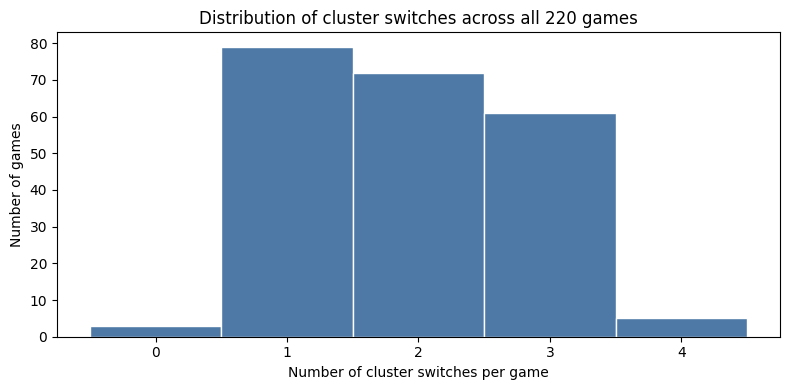

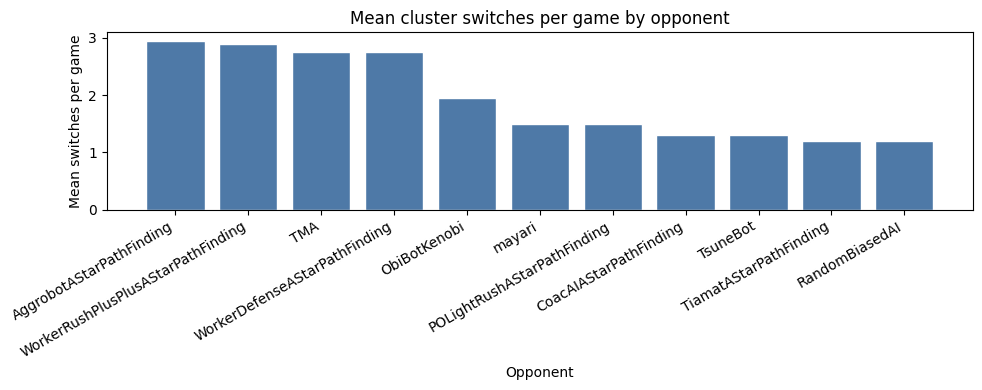

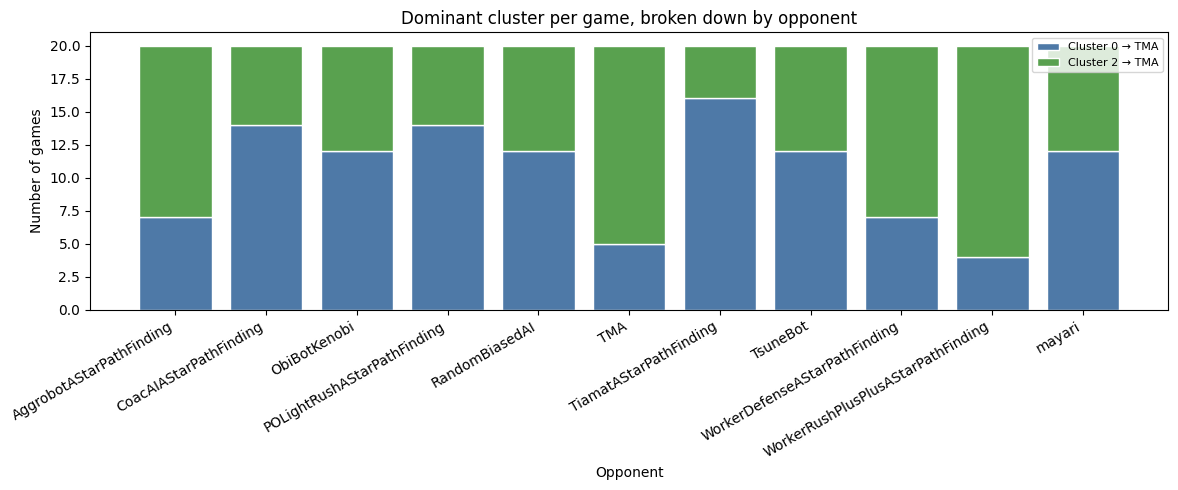

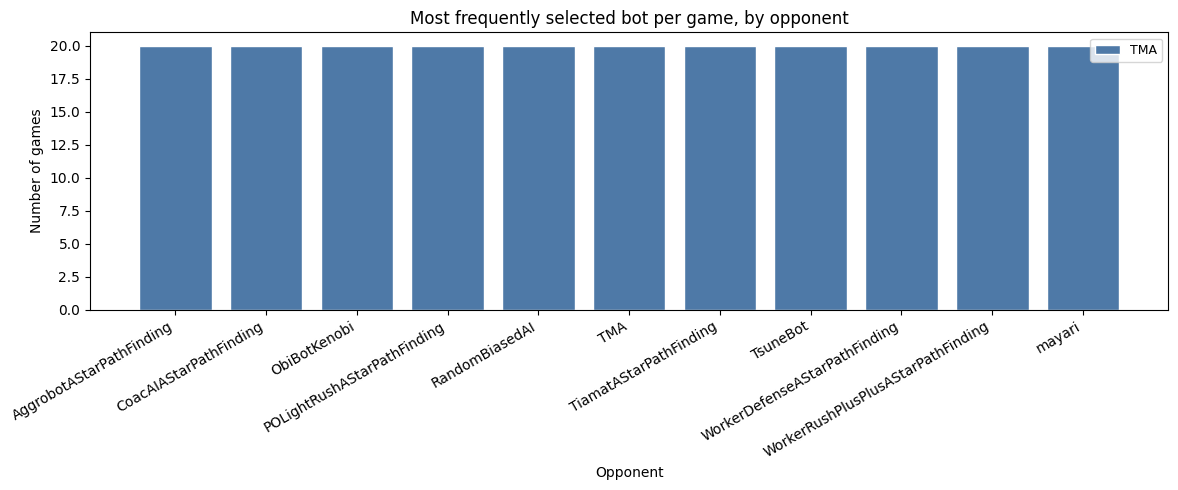

,games,mean_switches,max_switches,dominant_cluster,most_selected_bot
opponent,,,,,
AggrobotAStarPathFinding,20,2.95,4,2,TMA
CoacAIAStarPathFinding,20,1.30,2,0,TMA
ObiBotKenobi,20,1.95,3,0,TMA
POLightRushAStarPathFinding,20,1.50,2,0,TMA
RandomBiasedAI,20,1.20,2,0,TMA
TMA,20,2.75,3,2,TMA
TiamatAStarPathFinding,20,1.20,2,0,TMA
TsuneBot,20,1.30,2,0,TMA
WorkerDefenseAStarPathFinding,20,2.75,4,2,TMA


In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from collections import Counter

df = pd.DataFrame([{
    "opponent":         g["opponent"],
    "side":             g["side"],
    "winner":           g["winner"],
    "cycles":           g.get("cycles", 0),
    "switches":         g["switches"],
    "dominant_cluster": g["dominant_cluster"],
    "clusters":         g["clusters"],
    "times":            g["times"],
} for g in all_games])

CLUSTER_COLORS = {0:"#4e79a7", 1:"#f28e2b", 2:"#59a14f", 3:"#e15759",
                  4:"#b07aa1", 5:"#76b7b2", -1:"#aaaaaa"}

# cluster → best response bot label
CLUSTER_BOT = {0:"TMA", 1:"Aggrobot", 2:"TMA", 3:"TMA", 4:"Aggrobot", 5:"ObiBotKenobi"}

opponents = sorted(df["opponent"].unique())

# ── PLOT 1: switch count histogram ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["switches"], bins=range(0, df["switches"].max() + 2), color="#4e79a7",
        edgecolor="white", align="left")
ax.set_xlabel("Number of cluster switches per game")
ax.set_ylabel("Number of games")
ax.set_title("Distribution of cluster switches across all 220 games")
plt.tight_layout()
plt.savefig("switch_histogram.png", dpi=150)
plt.show()

# ── PLOT 2: mean switches per opponent ───────────────────────────────────────
mean_sw = df.groupby("opponent")["switches"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(mean_sw.index, mean_sw.values, color="#4e79a7", edgecolor="white")
ax.set_xlabel("Opponent")
ax.set_ylabel("Mean switches per game")
ax.set_title("Mean cluster switches per game by opponent")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("switches_per_opponent.png", dpi=150)
plt.show()

# ── PLOT 3: dominant cluster frequency per opponent ──────────────────────────
cluster_ids = sorted(df["dominant_cluster"].unique())
opp_cluster = pd.crosstab(df["opponent"], df["dominant_cluster"])
opp_cluster = opp_cluster.reindex(columns=cluster_ids, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(opp_cluster))
for c in cluster_ids:
    vals = opp_cluster[c].values
    color = CLUSTER_COLORS.get(c, "#aaaaaa")
    label = f"Cluster {c} → {CLUSTER_BOT.get(c, '?')}"
    ax.bar(opp_cluster.index, vals, bottom=bottom, color=color,
           edgecolor="white", label=label)
    bottom += vals

ax.set_xlabel("Opponent")
ax.set_ylabel("Number of games")
ax.set_title("Dominant cluster per game, broken down by opponent")
ax.legend(loc="upper right", fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("dominant_cluster_per_opponent.png", dpi=150)
plt.show()

# ── PLOT 4: bot selected most often per opponent (from dominant cluster) ─────
df["bot_selected"] = df["dominant_cluster"].map(CLUSTER_BOT).fillna("Unknown")
bot_counts = pd.crosstab(df["opponent"], df["bot_selected"])
bot_colors = {"Aggrobot":"#f28e2b", "TMA":"#4e79a7", "ObiBotKenobi":"#59a14f", "Unknown":"#aaaaaa"}

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(bot_counts))
for bot in bot_counts.columns:
    vals = bot_counts[bot].values
    ax.bar(bot_counts.index, vals, bottom=bottom,
           color=bot_colors.get(bot, "#aaaaaa"), edgecolor="white", label=bot)
    bottom += vals

ax.set_xlabel("Opponent")
ax.set_ylabel("Number of games")
ax.set_title("Most frequently selected bot per game, by opponent")
ax.legend(loc="upper right", fontsize=9)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("bot_selected_per_opponent.png", dpi=150)
plt.show()

# ── summary table ─────────────────────────────────────────────────────────────
summary = df.groupby("opponent").agg(
    games=("switches", "count"),
    mean_switches=("switches", "mean"),
    max_switches=("switches", "max"),
    dominant_cluster=("dominant_cluster", lambda x: x.value_counts().idxmax()),
    most_selected_bot=("bot_selected", lambda x: x.value_counts().idxmax()),
).round(2)
display(summary)

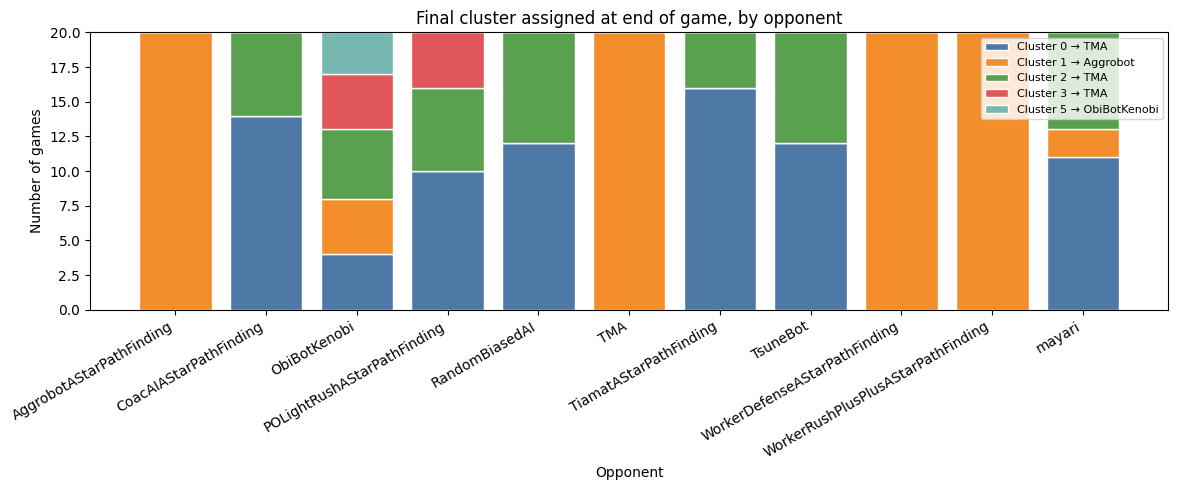

,opponent,games,most_common_final_cluster,final_cluster_count,final_bot_selected,consistency_%
0,AggrobotAStarPathFinding,20,1,20,Aggrobot,100.0%
8,WorkerDefenseAStarPathFinding,20,1,20,Aggrobot,100.0%
5,TMA,20,1,20,Aggrobot,100.0%
9,WorkerRushPlusPlusAStarPathFinding,20,1,20,Aggrobot,100.0%
6,TiamatAStarPathFinding,20,0,16,TMA,80.0%
1,CoacAIAStarPathFinding,20,0,14,TMA,70.0%
7,TsuneBot,20,0,12,TMA,60.0%
4,RandomBiasedAI,20,0,12,TMA,60.0%
10,mayari,20,0,11,TMA,55.0%
3,POLightRushAStarPathFinding,20,0,10,TMA,50.0%


In [32]:
# ── PLOT 5: final cluster per game, stacked bar by opponent ──────────────────
df["final_cluster"] = df["clusters"].apply(lambda c: c[-1] if c else -1)
df["final_bot"] = df["final_cluster"].map(CLUSTER_BOT).fillna("Unknown")

final_cluster_counts = pd.crosstab(df["opponent"], df["final_cluster"])
final_cluster_counts = final_cluster_counts.reindex(
    columns=sorted(df["final_cluster"].unique()), fill_value=0
)

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(final_cluster_counts))
for c in final_cluster_counts.columns:
    vals = final_cluster_counts[c].values
    color = CLUSTER_COLORS.get(c, "#aaaaaa")
    label = f"Cluster {c} → {CLUSTER_BOT.get(c, '?')}"
    ax.bar(final_cluster_counts.index, vals, bottom=bottom,
           color=color, edgecolor="white", label=label)
    bottom += vals

ax.set_xlabel("Opponent")
ax.set_ylabel("Number of games")
ax.set_title("Final cluster assigned at end of game, by opponent")
ax.legend(loc="upper right", fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("final_cluster_per_opponent.png", dpi=150)
plt.show()

# ── TABLE: most common final cluster and bot for each opponent ────────────────
final_summary = df.groupby("opponent").agg(
    games=("final_cluster", "count"),
    most_common_final_cluster=("final_cluster",
                               lambda x: x.value_counts().idxmax()),
    final_cluster_count=("final_cluster",
                         lambda x: x.value_counts().iloc[0]),
    final_bot_selected=("final_bot",
                        lambda x: x.value_counts().idxmax()),
).reset_index()

# add percentage column: how often the most common final cluster appears
final_summary["consistency_%"] = (
    final_summary["final_cluster_count"] / final_summary["games"] * 100
).round(1)

final_summary = final_summary.sort_values("consistency_%", ascending=False)

display(
    final_summary.style.format({"consistency_%": "{:.1f}%"})
                       .set_caption("Most common final cluster and bot selected, by opponent")
)

In [33]:
# ── TABLE: total cluster identifications and average time of identification ───

cluster_times = defaultdict(list)

for g in all_games:
    for cluster, time in zip(g["clusters"], g["times"]):
        cluster_times[cluster].append(time)

cluster_summary = []
for cluster in sorted(cluster_times.keys()):
    times = cluster_times[cluster]
    cluster_summary.append({
        "cluster": cluster,
        "bot_response": CLUSTER_BOT.get(cluster, "Unknown"),
        "total_identifications": len(times),
        "avg_time": round(sum(times) / len(times), 1),
        "min_time": min(times),
        "max_time": max(times),
    })

df_cluster_summary = pd.DataFrame(cluster_summary).sort_values(
    "total_identifications", ascending=False
)

display(
    df_cluster_summary.style
        .format({
            "avg_time": "{:.1f}",
            "min_time": "{:.0f}",
            "max_time": "{:.0f}",
        })
        .set_caption("Cluster identification frequency and timing across all 220 games")
)

,cluster,bot_response,total_identifications,avg_time,min_time,max_time
2,2,TMA,327,114.0,41,651
0,0,TMA,222,137.7,121,571
1,1,Aggrobot,86,714.3,571,891
3,3,TMA,8,426.0,411,441
4,5,ObiBotKenobi,3,411.0,411,411
